# Speech → Indian Sign Language
### A retrieval-based demonstration system — Phase 0

**Course:** Speech Processing (22AIE450) · Amrita School of Artificial Intelligence, Coimbatore
**Student:** Mothishwaran · Roll 41 · AIE-A
**Review 1 · August 2026**

---

## What this notebook is

A complete, honest walkthrough of the project: the problem, the literature, the research gaps,
the speech-processing theory, every line of the working system, and the measured results.

Read it top to bottom and you will understand the whole project.

## What this system IS

> A person speaks English. The system recognises the speech, looks each word up in a small
> dictionary of **real Indian Sign Language video clips recorded by Deaf signers**, and plays
> the matching clips back in order.

## What this system is NOT

**It is not translation.** This distinction is the single most important thing in this notebook,
and it is stated up front rather than buried at the end.

| We do | We do NOT |
|---|---|
| Retrieve pre-recorded clips of real human signers | Generate or synthesise any signing |
| Match words and short phrases exactly | Understand meaning or context |
| Play clips in English word order | Produce correct ISL grammar |
| Report honestly what fraction of words we covered | Claim the output is fluent ISL |

Indian Sign Language is a **complete natural language with its own grammar** — not English
performed with the hands. Concatenating dictionary clips in English word order produces, at
best, "signed English". We say so throughout, and Section 15 lists every limitation explicitly.

---
# Table of contents

| § | Section | What it covers |
|---|---|---|
| 1 | Problem and motivation | Why speech→ISL, why India |
| 2 | Literature review | 10 verified papers, grouped, with links |
| 3 | Research gaps | Three gaps, each traced to the papers above |
| 4 | System overview | The pipeline, end to end |
| 5 | Dataset | ISLRTC clips, the manifest, licensing |
| 6 | Speech processing theory | Sampling, framing, windowing, spectrograms, MFCC |
| 7 | Speech recognition | What Whisper is and how we configured it |
| 8 | Text normalisation | Turning a transcript into clean tokens |
| 9 | The matching algorithm | Longest-n-gram retrieval |
| 10 | Fingerspelling | The fallback for names |
| 11 | Serving the system | API and browser front end |
| 12 | Running the demo | End-to-end test |
| 13 | Evaluation design | What we measure and what it means |
| 14 | Results | Measured numbers and findings |
| 15 | Limitations | What this system genuinely cannot do |
| 16 | Pending work | Phases 1–4 |
| 17 | References | IEEE format |

---
# § 0 · Setup

Run this first. It confirms the environment and imports the project modules.

Everything runs on **CPU only** and, once the model is cached, **fully offline**.

In [1]:
import os, sys, json, csv, wave, time
import numpy as np

# Run from the project root so relative paths in the modules resolve.
if os.path.basename(os.getcwd()) == "tools":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

print("working dir :", os.getcwd())
print("python      :", sys.version.split()[0])
print("numpy       :", np.__version__)

working dir : D:\sem 7\speak\sign_pro\speechtosign
python      : 3.11.9
numpy       : 2.4.6


In [2]:
# Project modules. Each is small and does exactly one job.
from src import matcher, fingerspell

print("matcher    ->", matcher.__doc__.splitlines()[0])
print("fingerspell->", fingerspell.__doc__.splitlines()[0])

matcher    -> Longest-n-gram lookup against the manifest. See plans/02_SPEC.md section 4.
fingerspell-> Name fingerspelling fallback. See plans/02_SPEC.md section 5.


---
# § 1 · Problem and motivation

## The communication gap

India has one of the world's largest Deaf and hard-of-hearing populations. Indian Sign Language
(ISL) is their primary language. But almost nobody outside the Deaf community signs, and
qualified ISL interpreters are extremely scarce relative to the population that needs them.

So an ordinary interaction — a hospital reception desk, a railway counter, a classroom — has no
shared language on either side.

## What would actually help

A system that takes **spoken English** and shows **Indian Sign Language video**, live.

## Why this is genuinely hard

1. **Sign language is not a writing system for speech.** ISL has its own grammar, its own word
   order, and uses the space in front of the signer to carry meaning.
2. **Meaning lives in the face and body too**, not just the hands. Raised eyebrows can turn a
   statement into a question. These are called *non-manual markers*.
3. **ISL has very little machine-readable data** compared to American or German Sign Language.
4. **Generating realistic signing is an unsolved research problem** — see § 2 and § 3.

## The design decision this project makes

Because generating signing is unsolved, we **do not generate anything**. We retrieve and play
**real video of real Deaf signers** from the government ISL dictionary.

This trades away flexibility (we can only show words we have clips for) in exchange for the
output being genuine, human, correctly-articulated signing. § 2 and § 3 explain why the
literature supports that trade.

---
# § 2 · Literature review

Ten papers. Every citation below was **checked against the publisher's own page** — the links
go to ACL Anthology, CVF Open Access, PMLR, Springer, ACM or ISCA, not to a citation generator.

They are grouped by theme, because the grouping is itself the argument: the field has good
*recognition* of sign language, weak *production* of it, and almost nothing for ISL.

## Group A — Speech recognition (the input side)

### [1] Whisper — the speech recogniser we actually use

> Radford, Kim, Xu, Brockman, McLeavey, Sutskever, **"Robust Speech Recognition via Large-Scale
> Weak Supervision"**, *ICML 2023*, PMLR vol. 202, pp. 28492–28518.
> 🔗 https://proceedings.mlr.press/v202/radford23a.html

**In simple terms:** OpenAI trained one speech-recognition model on **680,000 hours** of audio
scraped from the internet with imperfect labels. The lesson of the paper is that *enormous
messy data beats small clean data* — the model works on accents, noise and microphones it has
never seen, with no fine-tuning.

**Why we use it:** it works out of the box on Indian-accented English, runs on a laptop CPU, and
needs no training data of our own. We use the `base.en` variant.

**What it does NOT solve for us:** it only produces English text. Everything after that — the
actual sign language problem — is ours.

## Group B — Indian Sign Language datasets (the resource problem)

### [2] ISLTranslate — the biggest ISL sentence-level dataset

> Joshi, Agrawal, Modi, **"ISLTranslate: Dataset for Translating Indian Sign Language"**,
> *Findings of ACL 2023*.
> 🔗 https://aclanthology.org/2023.findings-acl.665/

**In simple terms:** ~**31,000** pairs of (ISL video, English sentence). The largest translation
dataset for continuous ISL. Licensed CC-BY-NC — research use, attribution required, no commercial use.

**Why it matters to us:** this is our **Phase 1** corpus. We are *not* using it in Phase 0, and
we are careful never to imply otherwise.

### [3] iSign — a larger, more recent ISL benchmark

> Joshi et al., **"iSign: A Benchmark for Indian Sign Language Processing"**,
> *Findings of ACL 2024*, pp. 10827–10844.
> 🔗 https://aclanthology.org/2024.findings-acl.643/

**In simple terms:** over **118,000** video–sentence pairs plus a set of standard tasks
(video→text, pose→text, text→pose, word prediction, sign semantics) so different research groups
can compare fairly.

**Why it matters:** it is the current state of ISL resources, and it shows the field is finally
building infrastructure for ISL. It is our expansion option if ISLTranslate proves too small.

### [4] INCLUDE — isolated ISL word recognition

> Sridhar, Ganesan, Kumar, Khapra, **"INCLUDE: A Large Scale Dataset for Indian Sign Language
> Recognition"**, *ACM Multimedia 2020*, pp. 1366–1375.
> 🔗 https://www.semanticscholar.org/paper/fd9642b9a64553e36184565f1d21a2fa43b41362

**In simple terms:** 4,287 videos covering 263 individual word-signs, recorded with experienced signers.

**Why it matters:** it is representative of ISL resources generally — **isolated words, not
continuous sentences.** That imbalance is exactly Gap 1 in § 3.

## Group C — Sign language translation and production (the state of the art)

### [5] Neural Sign Language Translation — the paper that started the field

> Camgöz, Hadfield, Koller, Ney, Bowden, **"Neural Sign Language Translation"**,
> *CVPR 2018*, pp. 7784–7793.
> 🔗 https://openaccess.thecvf.com/content_cvpr_2018/html/Camgoz_Neural_Sign_Language_CVPR_2018_paper.html

**In simple terms:** the first work to treat sign→text as a proper machine-translation problem,
explicitly handling the fact that sign order and spoken order differ. It also introduced
**RWTH-PHOENIX-Weather 2014T** (German Sign Language weather forecasts) — still the standard
benchmark.

**Why it matters:** PHOENIX14T is the yardstick the whole field measures against, and it is
German. Nothing of comparable quality exists for ISL. That contrast is Gap 1.

### [6] Sign Language Transformers — the modern architecture

> Camgöz, Koller, Hadfield, Bowden, **"Sign Language Transformers: Joint End-to-End Sign Language
> Recognition and Translation"**, *CVPR 2020*, pp. 10023–10033.
> 🔗 https://openaccess.thecvf.com/content_CVPR_2020/papers/Camgoz_Sign_Language_Transformers_Joint_End-to-End_Sign_Language_Recognition_and_Translation_CVPR_2020_paper.pdf

**In simple terms:** one transformer that learns to recognise signs and translate them at the
same time, using a CTC loss to tie the two tasks together. Roughly doubled previous scores.

**Why it matters:** this is sign **→** text. Our project is the opposite direction, which is the
much harder and much less solved one.

### [7] Progressive Transformers — text → sign *production*

> Saunders, Camgöz, Bowden, **"Progressive Transformers for End-to-End Sign Language
> Production"**, *ECCV 2020*, pp. 687–705.
> 🔗 https://link.springer.com/chapter/10.1007/978-3-030-58621-8_40

**In simple terms:** the first end-to-end model that goes from a written sentence to a
continuous sequence of 3D sign poses — a skeleton, not a video of a person.

**Why it matters most to us:** this is the closest thing to "what we are not attempting". Output
is stick-figure pose sequences, still research-grade, and the paper itself frames human-level
translation as the goal rather than the achievement. **This is the direct evidence for choosing
retrieval over generation.**

## Group D — Speech → sign directly (the closest prior work to us)

### [8] Towards Automatic Speech to Sign Language Generation

> Kapoor, Mukhopadhyay, Hegde, Namboodiri, Jawahar, **"Towards Automatic Speech to Sign Language
> Generation"**, *Interspeech 2021*.
> 🔗 https://www.isca-archive.org/interspeech_2021/kapoor21_interspeech.html

**In simple terms:** goes straight from **speech audio** to sign pose sequences, skipping text
entirely, using a multi-tasking transformer. They also released the first ISL dataset with
speech-level annotations.

**Why this one matters enormously:** it is the same input and the same output and the same
language as our project — Indian Sign Language, driven by speech. It is the paper an examiner is
most likely to ask us to compare against.

**How we differ, honestly:** they *generate* poses; we *retrieve* real video. Theirs is more
ambitious and more general. Ours is simpler, produces genuine human signing, and is honestly
measurable. We do not claim to beat it.

## Group E — Retrieval (the method for Phase 1)

### [9] Sentence-BERT — comparing sentences by meaning

> Reimers, Gurevych, **"Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks"**,
> *EMNLP-IJCNLP 2019*, pp. 3982–3992.
> 🔗 https://aclanthology.org/D19-1410/

**In simple terms:** turns a whole sentence into a single vector, so two sentences that *mean*
the same thing sit close together even when the words differ. Finding the closest pair drops
from ~65 hours with plain BERT to ~5 seconds.

**Why it matters:** this is how Phase 1 will match "could you help me" to a stored clip for
"please help", which exact matching can never do. **We are not using it in Phase 0** — Phase 0
is deliberately exact-match only.

## Group F — How Deaf people actually receive this technology

This group decides our architecture. Skipping it would make the whole project an engineering
exercise with no grounding in its users.

### [10] Attitudes toward signing avatars

> Quandt, Willis, Schwenk, Weeks, Ferster, **"Attitudes Toward Signing Avatars Vary Depending on
> Hearing Status, Age of Signed Language Acquisition, and Avatar Type"**,
> *Frontiers in Psychology*, vol. 13, art. 730917, 2022.
> 🔗 https://www.frontiersin.org/journals/psychology/articles/10.3389/fpsyg.2022.730917/full

**In simple terms — and read this carefully, because the popular summary of it is wrong:**

Deaf participants rated signing avatars **significantly lower** than hard-of-hearing or hearing
participants did. But the study found this depends on **avatar type**:

- **Computer-synthesised** avatars were rated harshly by Deaf signers.
- **Motion-capture** avatars — driven by a recording of a real human's movement — were **not**
  rated harshly.

The authors' interpretation: fluent signers are **expert judges of movement quality**. They are
not rejecting avatars in principle; they are detecting unnatural motion that less fluent viewers
miss.

**Why this is the single most useful paper for us.** The problem is *movement naturalness*, and
the closer the motion is to a real human, the better it is received. Retrieving **actual video of
actual Deaf signers** is the limit case of that spectrum — the motion is not approximated at all.

> ⚠️ **Accuracy note.** An earlier draft of our own plan claimed this literature shows avatars are
> "rejected by Deaf users". That overstates it and we corrected it. The finding is
> *conditional*: attitudes depend on hearing status, age of sign acquisition, and avatar type.
> Stating it correctly is stronger than overstating it — and an examiner who knows the paper will
> catch the overclaim.

**Related, also verified:** Kipp, Heloir, Nguyen, *"Assessing the deaf user perspective on sign
language avatars"*, ASSETS 2011 — 🔗 https://dl.acm.org/doi/10.1145/2049536.2049557

---
# § 3 · Research gaps

A gap is only worth stating if it points at real papers. Each of these traces to § 2.

## Gap 1 — Indian Sign Language is severely under-resourced

The standard sign-language benchmark, **PHOENIX14T [5]**, is German. The bulk of translation
research targets German and American Sign Language. ISL resources are far newer and smaller
(**ISLTranslate [2]**, 2023, ~31k pairs; **iSign [3]**, 2024, ~118k), and what exists for ISL
skews toward **isolated words** (**INCLUDE [4]**) rather than continuous signing.

**Consequence:** methods that assume a large annotated corpus cannot simply be transferred to ISL.

## Gap 2 — Sign language *production* is unsolved, and output quality is judged by movement naturalness

Recognition (sign→text) is mature (**[5]**, **[6]**). Production (text/speech→sign) is not:
**Progressive Transformers [7]** outputs 3D pose skeletons, and **Kapoor et al. [8]** — the closest
work to ours — also outputs poses rather than natural video.

Meanwhile **Quandt et al. [10]** show Deaf viewers are sensitive specifically to **unnatural
movement**, rating computer-synthesised avatars poorly while accepting motion-captured ones.

**Consequence:** synthesising signing risks producing exactly the artefact the target users are
most sensitive to. Using real recorded human signers avoids that failure mode entirely.

## Gap 3 — Retrieval-based speech→ISL has not been systematically evaluated

**[8]** attacks speech→sign by *generation*. **[9]** provides the retrieval machinery. But we
found no work that treats speech→ISL as a **retrieval** problem and reports honest coverage
against a fixed sign inventory.

**This gap is our contribution**, and we state it in one sentence:

> We test whether retrieving real ISL signer video, driven by automatic speech recognition, is a
> workable and *honestly measurable* alternative to generating sign language — and we report what
> fraction of speech such a system can actually cover.

The phrase **"honestly measurable"** is doing real work there. A generation system can always
output *something*; you cannot tell from the output alone whether it is correct. A retrieval
system either has the clip or it does not — so its failures are visible and countable. That is
the methodological argument for this design.

---
# § 4 · System overview

```
 ┌──────────┐   ┌───────────────┐   ┌──────────────────────┐   ┌───────────────┐
 │  Speech  │──▶│  Microphone   │──▶│  16 kHz mono audio   │──▶│    Whisper    │
 │ (person) │   │  push-to-talk │   │  (PCM, single chan.) │   │  base.en int8 │
 └──────────┘   └───────────────┘   └──────────────────────┘   └───────┬───────┘
                                                                       │ English text
                                                                       ▼
                                                        ┌──────────────────────────┐
                                                        │  Normalise + tokenise    │
                                                        │  lowercase, strip punct. │
                                                        └────────────┬─────────────┘
                                                                     ▼
                                                        ┌──────────────────────────┐
                                                        │  Longest-n-gram lookup   │
                                                        │  against manifest.csv    │
                                                        └────────────┬─────────────┘
                              ┌──────────────────────────────────────┼──────────────────────────┐
                              ▼                                      ▼                          ▼
                     ┌─────────────────┐                  ┌────────────────────┐      ┌──────────────────┐
                     │ FOUND → "sign"  │                  │ CAPITALISED name   │      │ NOT FOUND        │
                     │ play ISL clip   │                  │ → "spell"          │      │ → "uncovered"    │
                     │                 │                  │ fingerspell letters│      │ drop, and COUNT  │
                     └────────┬────────┘                  └─────────┬──────────┘      └──────────────────┘
                              └──────────────┬─────────────────────-┘
                                             ▼
                              ┌──────────────────────────────┐
                              │ Preload all clips, then play │
                              │ sequentially in the browser  │
                              └──────────────────────────────┘
```

## The three outcomes for every word

This three-way split is the entire intellectual content of the system.

| Outcome | Meaning | What the user sees |
|---|---|---|
| **sign** | Word/phrase exists in our ISL dictionary | The real ISL clip plays |
| **spell** | Looks like a proper noun (capitalised mid-sentence) | Fingerspelled letter by letter |
| **uncovered** | Not in the dictionary, not a name | **Nothing plays — and we count it** |

**Why "uncovered" matters more than it looks.** The lazy design would fingerspell every unknown
word. That produces an unreadable wall of letters, and it *hides* the system's limits behind
apparent activity. Dropping the word and counting it makes the limitation visible and gives us a
real metric. § 13 defines that metric.

---
# § 5 · Dataset

## Source: the ISLRTC Indian Sign Language Dictionary

**ISLRTC** — the Indian Sign Language Research and Training Centre, an autonomous body under the
Department of Empowerment of Persons with Disabilities, Government of India.

| Property | Detail |
|---|---|
| Size | ~10,000 terms |
| Signers | Deaf signers (per ISLRTC) |
| Categories | Academic, agricultural, everyday, technical, legal |
| Distribution | ISLRTC website, YouTube, Google Drive, DIKSHA |
| Official page | https://islrtc.nic.in/isl-dictionary/ |
| Open-data entry | https://data.gov.in/catalog/indian-sign-language-dictionary |

The alphabet (fingerspelling) clips come from the ISL portal maintained by **FDMSE, RKMVERI,
Coimbatore** — 🔗 https://indiansignlanguage.org/category/alphabets/

> **Note on the ISL manual alphabet:** ISL uses a **two-handed** alphabet, unlike American and
> British Sign Language which are one-handed. We use the two-handed set consistently.

## What we actually use in Phase 0

Deliberately tiny. Five words plus one multi-word phrase, so the *pipeline* can be proven before
the vocabulary is grown. Adding a word later is **one row in a CSV and one video file** — no code
change.

## Licensing — and why no video is in our repository

We commit **`manifest.csv` with a source URL for every clip**, and we **never commit the video
files themselves**. The dataset is therefore fully reconstructible from the repository without us
redistributing government-licensed material.

This matters practically: "available for academic use" is *not* the same as "free to
redistribute", and ISLTranslate's CC-BY-NC licence would forbid commercial use outright.

In [3]:
# The manifest is the single source of truth for the sign vocabulary.
import csv

with open("data/manifest.csv", newline="", encoding="utf-8") as f:
    rows = list(csv.DictReader(f))

print(f"{len(rows)} entries in the sign dictionary  (first 6 and a few longer phrases shown)\n")
print(f"{'id':<16}{'phrase':<18}{'words':<7}{'licence':<10}clip")
print("-" * 78)
sample = rows[:6] + [r for r in rows if int(r["ngram_len"]) >= 4][:4]
for r in sample:
    print(f"{r['id'][:15]:<16}{r['phrase'][:17]:<18}{r['ngram_len']:<7}{r['license']:<10}{r['local_path']}")

4068 entries in the sign dictionary  (first 6 and a few longer phrases shown)

id              phrase            words  licence   clip
------------------------------------------------------------------------------
1               1                 1      ISLRTC    data/_source/isl_dictionary/Numbers/1_One.mp4
10              10                1      ISLRTC    data/_source/isl_dictionary/Numbers/10_Ten.mp4
100             100               1      ISLRTC    data/_source/isl_dictionary/Numbers/100_Hundred.mp4
1000            1000              1      ISLRTC    data/_source/isl_dictionary/Numbers/1000_Thousand.mp4
10000           10000             1      ISLRTC    data/_source/isl_dictionary/Numbers/10000_Ten_Thousand.mp4
100000          100000            1      ISLRTC    data/_source/isl_dictionary/Numbers/100000_One_Lakh.mp4
advantage_of_ki advantage of kitc 4      ISLRTC    data/_source/isl_dictionary/A/Advantage_of_Kitchen_Gardening.mp4
angular_leat_sp angular leat spot 5      ISLRTC   

In [4]:
# Verify every clip the manifest promises actually exists on disk,
# plus the 10 alphabet letters needed to fingerspell "Mothishwaran".
import os

missing = [r["local_path"] for r in rows if not os.path.exists(r["local_path"])]
print("sign clips present :", len(rows) - len(missing), "/", len(rows))
if missing:
    print("  MISSING:", missing)

needed = sorted(set("mothishwaran"))
have = [c for c in needed if os.path.exists(f"data/alphabet/{c}.mp4")]
print(f"alphabet letters   : {len(have)}/{len(needed)} needed for the demo name")

total = len([f for f in os.listdir("data/alphabet") if f.endswith(".mp4")])
print(f"alphabet clips     : {total} total (full A-Z available)")

sign clips present : 4068 / 4068
alphabet letters   : 10/10 needed for the demo name
alphabet clips     : 26 total (full A-Z available)


---
# § 6 · Speech processing theory

This is the core of the course, so it gets treated properly. Everything below is computed from
our own audio file — nothing is copied from a textbook figure.

## 6.1 Sound → numbers: sampling

Sound is a continuous pressure wave. A computer stores **samples** — the wave's height measured
many times per second.

**Sampling rate** = samples per second. We use **16,000 Hz (16 kHz)**.

### Why 16 kHz? The Nyquist–Shannon theorem

> To represent a signal containing frequencies up to *f*, you must sample at **at least 2·f**.

Reversed: sampling at 16 kHz faithfully captures everything **up to 8 kHz**.

Speech intelligibility lives almost entirely below 8 kHz. Telephones used 8 kHz sampling (4 kHz
ceiling), which is why phone audio blurs `/s/` and `/f/` — those fricatives carry energy above
4 kHz. 16 kHz keeps them.

Whisper's front end expects exactly 16 kHz, so this is also a hard requirement, not just a choice.

**Sampling below Nyquist causes *aliasing*** — high frequencies fold back and masquerade as low
ones, corrupting the signal irreversibly.

## 6.2 Bit depth

Each sample is stored as a 16-bit integer (**PCM16**): 65,536 possible amplitude levels. Fewer
bits would add audible quantisation noise.

Our audio is **mono** — one channel. Two microphones give no benefit for single-speaker ASR and
would double the data.

In [5]:
import wave
import numpy as np
import matplotlib.pyplot as plt

PATH = "eval/sample.wav"
with wave.open(PATH, "rb") as w:
    sr        = w.getframerate()
    n_ch      = w.getnchannels()
    width     = w.getsampwidth()
    n_frames  = w.getnframes()
    raw       = w.readframes(n_frames)

signal = np.frombuffer(raw, dtype=np.int16).astype(np.float32) / 32768.0
if n_ch > 1:
    signal = signal.reshape(-1, n_ch).mean(axis=1)

print(f"file          : {PATH}")
print(f"sample rate   : {sr} Hz      -> Nyquist limit = {sr//2} Hz")
print(f"channels      : {n_ch} (mono)")
print(f"bit depth     : {width*8}-bit PCM")
print(f"samples       : {len(signal):,}")
print(f"duration      : {len(signal)/sr:.2f} s")
print(f"amplitude     : min {signal.min():+.3f}   max {signal.max():+.3f}")

file          : eval/sample.wav
sample rate   : 16000 Hz      -> Nyquist limit = 8000 Hz
channels      : 1 (mono)
bit depth     : 16-bit PCM
samples       : 70,640
duration      : 4.42 s
amplitude     : min -0.601   max +0.946


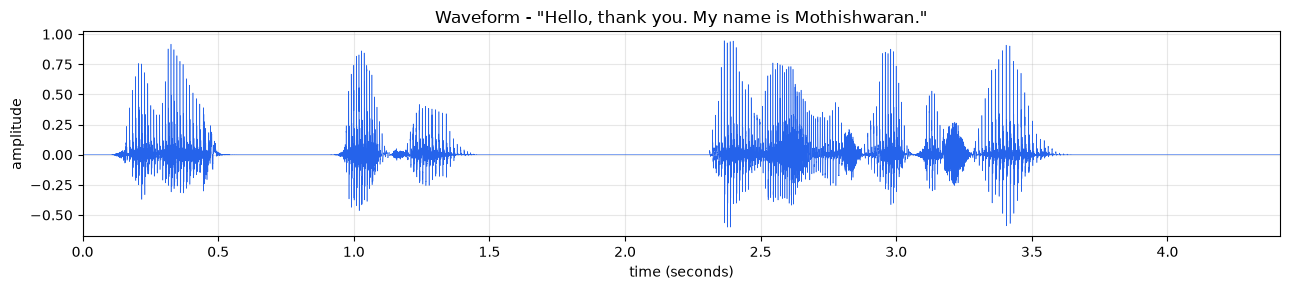

In [6]:
# The waveform: amplitude over time. You can see where words are and where silence is,
# but you cannot see WHICH sounds they are. That needs frequency analysis.
t = np.arange(len(signal)) / sr

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(t, signal, linewidth=0.4, color="#2563eb")
ax.set_xlabel("time (seconds)")
ax.set_ylabel("amplitude")
ax.set_title('Waveform - "Hello, thank you. My name is Mothishwaran."')
ax.set_xlim(0, t[-1])
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6.3 Framing and windowing

Speech is **non-stationary** — it changes constantly. But over a *short* span (~20–30 ms) the
vocal tract barely moves, so the signal is approximately **stationary**. That short span is a
**frame**.

| Parameter | Typical | Why |
|---|---|---|
| Frame length | 25 ms | Long enough to measure pitch, short enough to be stationary |
| Hop (stride) | 10 ms | Frames overlap 60%, so no transient is lost at a boundary |

### Why we apply a window function

Cutting a frame with a hard edge (a *rectangular* window) chops the waveform mid-cycle. The FFT
assumes the frame repeats forever, so that discontinuity injects fake frequencies across the whole
spectrum — **spectral leakage**.

A **Hamming window** tapers smoothly to near zero at both edges, so the frame joins itself
cleanly. Cost: a slightly wider main lobe (a little less frequency resolution). Benefit: far lower
side lobes (much less leakage). For speech that trade is clearly worth it.

frame length : 25 ms = 400 samples
hop length   : 10 ms = 160 samples
overlap      : 60%


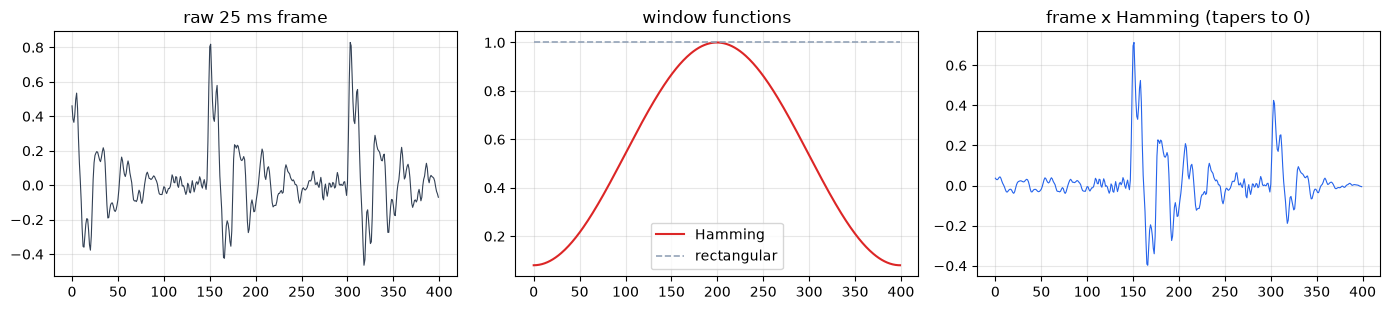

In [7]:
FRAME_MS, HOP_MS = 25, 10
frame_len = int(sr * FRAME_MS / 1000)
hop_len   = int(sr * HOP_MS   / 1000)

hamming = np.hamming(frame_len)
rect    = np.ones(frame_len)

print(f"frame length : {FRAME_MS} ms = {frame_len} samples")
print(f"hop length   : {HOP_MS} ms = {hop_len} samples")
print(f"overlap      : {100*(1-hop_len/frame_len):.0f}%")

start = int(1.0 * sr)                       # a frame from ~1 s in
seg = signal[start:start+frame_len]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))
axes[0].plot(seg, color="#334155", lw=0.8)
axes[0].set_title("raw 25 ms frame"); axes[0].grid(alpha=.3)
axes[1].plot(hamming, color="#dc2626", lw=1.5, label="Hamming")
axes[1].plot(rect, color="#94a3b8", lw=1.2, ls="--", label="rectangular")
axes[1].set_title("window functions"); axes[1].legend(); axes[1].grid(alpha=.3)
axes[2].plot(seg*hamming, color="#2563eb", lw=0.8)
axes[2].set_title("frame x Hamming (tapers to 0)"); axes[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

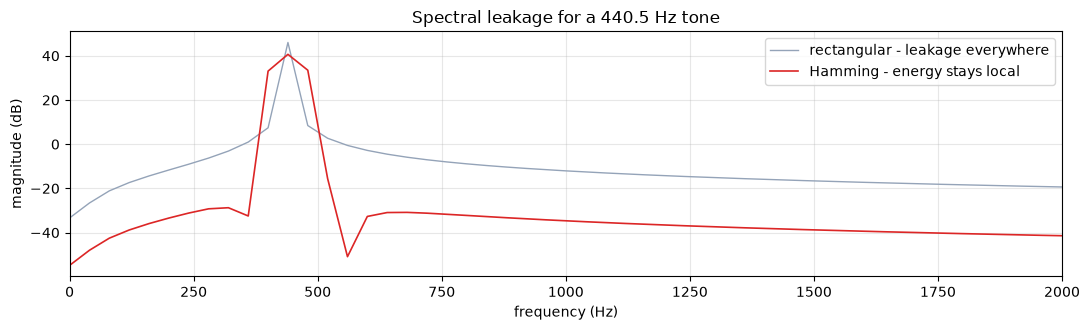

The grey curve smears energy across frequencies that are NOT in the signal.
That smearing is what the window function suppresses.


In [8]:
# Spectral leakage, measured rather than asserted: a pure tone that does not fit
# a whole number of cycles in the frame.
f0 = 440.5
tone = np.sin(2*np.pi*f0*np.arange(frame_len)/sr)

spec_rect = 20*np.log10(np.abs(np.fft.rfft(tone*rect))    + 1e-10)
spec_hamm = 20*np.log10(np.abs(np.fft.rfft(tone*hamming)) + 1e-10)
freqs = np.fft.rfftfreq(frame_len, 1/sr)

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(freqs, spec_rect, color="#94a3b8", lw=1, label="rectangular - leakage everywhere")
ax.plot(freqs, spec_hamm, color="#dc2626", lw=1.2, label="Hamming - energy stays local")
ax.set_xlim(0, 2000); ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("magnitude (dB)")
ax.set_title(f"Spectral leakage for a {f0} Hz tone"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print("The grey curve smears energy across frequencies that are NOT in the signal.")
print("That smearing is what the window function suppresses.")

## 6.4 The spectrogram

Take every frame, window it, run an **FFT**, keep the magnitude. Stack the results side by side
and you get a **spectrogram**: time on x, frequency on y, energy as colour.

This is the *Short-Time Fourier Transform* (STFT). It is where you can finally *see* speech —
the horizontal bands are **formants**, the resonances of the vocal tract that distinguish
vowels from one another.

spectrogram shape : (440, 201) = (frames, frequency bins)
frequency bins    : 201 covering 0 to 8000 Hz


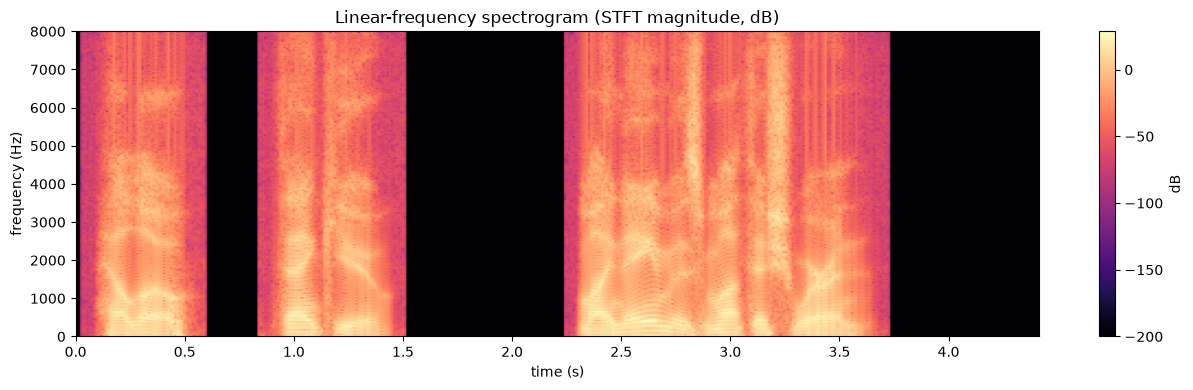

In [9]:
def stft_magnitude(x, frame_len, hop_len, window):
    n_frames = 1 + (len(x) - frame_len) // hop_len
    out = np.empty((n_frames, frame_len//2 + 1), dtype=np.float32)
    for i in range(n_frames):
        seg = x[i*hop_len : i*hop_len + frame_len] * window
        out[i] = np.abs(np.fft.rfft(seg))
    return out

mag = stft_magnitude(signal, frame_len, hop_len, hamming)
power = mag ** 2
print("spectrogram shape :", mag.shape, "= (frames, frequency bins)")
print("frequency bins    :", mag.shape[1], f"covering 0 to {sr//2} Hz")

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(20*np.log10(mag.T + 1e-10), origin="lower", aspect="auto",
               extent=[0, len(signal)/sr, 0, sr/2], cmap="magma")
ax.set_xlabel("time (s)"); ax.set_ylabel("frequency (Hz)")
ax.set_title("Linear-frequency spectrogram (STFT magnitude, dB)")
fig.colorbar(im, ax=ax, label="dB")
plt.tight_layout(); plt.show()

## 6.5 The mel scale — matching human hearing

Human pitch perception is **not linear**. The gap between 100 Hz and 200 Hz sounds huge; the gap
between 8000 Hz and 8100 Hz is inaudible. We hear roughly **logarithmically**.

The **mel scale** warps frequency to match that:

$$ m = 2595 \cdot \log_{10}\!\left(1 + \frac{f}{700}\right) $$

We then build overlapping triangular **filters**, evenly spaced *in mel*, and sum the spectrogram
energy inside each. Low frequencies get many narrow filters (fine detail where we hear well);
high frequencies get few wide ones.

This is both perceptually sensible **and** a big compression: 201 linear bins → 80 mel bins.

filterbank shape : (80, 201)


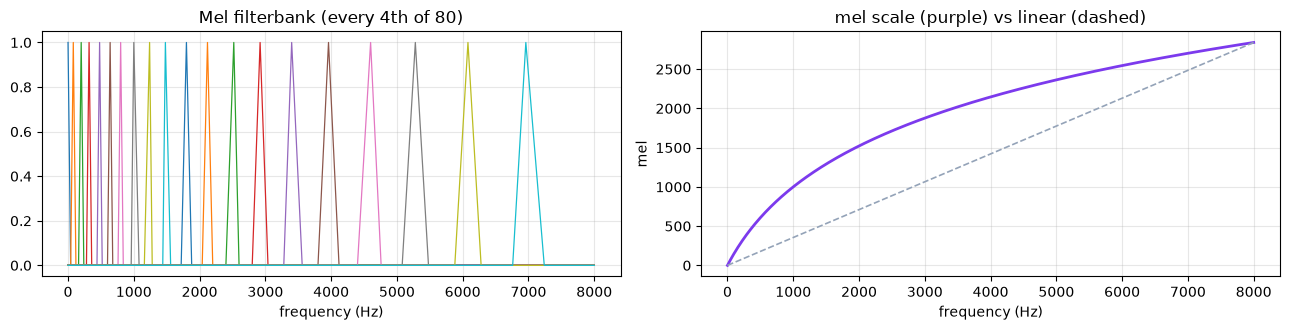


Filter spacing - note how they widen as frequency rises:
  filter  0: centred near      22 Hz
  filter 20: centred near     645 Hz
  filter 40: centred near    1806 Hz
  filter 60: centred near    3970 Hz
  filter 78: centred near    7475 Hz


In [10]:
def hz_to_mel(f):  return 2595.0 * np.log10(1.0 + f/700.0)
def mel_to_hz(m):  return 700.0 * (10**(m/2595.0) - 1.0)

def mel_filterbank(n_filters, n_fft, sr, fmin=0, fmax=None):
    fmax = fmax or sr/2
    mel_pts = np.linspace(hz_to_mel(fmin), hz_to_mel(fmax), n_filters + 2)
    hz_pts  = mel_to_hz(mel_pts)
    bins    = np.floor((n_fft + 1) * hz_pts / sr).astype(int)
    fb = np.zeros((n_filters, n_fft//2 + 1))
    for i in range(1, n_filters + 1):
        left, centre, right = bins[i-1], bins[i], bins[i+1]
        for k in range(left, centre):
            if centre > left:  fb[i-1, k] = (k - left) / (centre - left)
        for k in range(centre, right):
            if right > centre: fb[i-1, k] = (right - k) / (right - centre)
    return fb, hz_pts

N_MELS = 80                      # 80 is exactly what Whisper uses
fb, hz_pts = mel_filterbank(N_MELS, frame_len, sr)
print("filterbank shape :", fb.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
freqs = np.fft.rfftfreq(frame_len, 1/sr)
for i in range(0, N_MELS, 4):
    axes[0].plot(freqs, fb[i], lw=0.9)
axes[0].set_title(f"Mel filterbank (every 4th of {N_MELS})")
axes[0].set_xlabel("frequency (Hz)"); axes[0].grid(alpha=.3)

f_lin = np.linspace(0, sr/2, 500)
axes[1].plot(f_lin, hz_to_mel(f_lin), color="#7c3aed", lw=2)
axes[1].plot(f_lin, f_lin*(hz_to_mel(sr/2)/(sr/2)), ls="--", color="#94a3b8", lw=1.2)
axes[1].set_title("mel scale (purple) vs linear (dashed)")
axes[1].set_xlabel("frequency (Hz)"); axes[1].set_ylabel("mel"); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print("\nFilter spacing - note how they widen as frequency rises:")
for i in [0, 20, 40, 60, 78]:
    print(f"  filter {i:>2}: centred near {hz_pts[i+1]:7.0f} Hz")

linear spectrogram : (440, 201)
log-mel spectrogram: (440, 80)  <- 201 bins compressed to 80


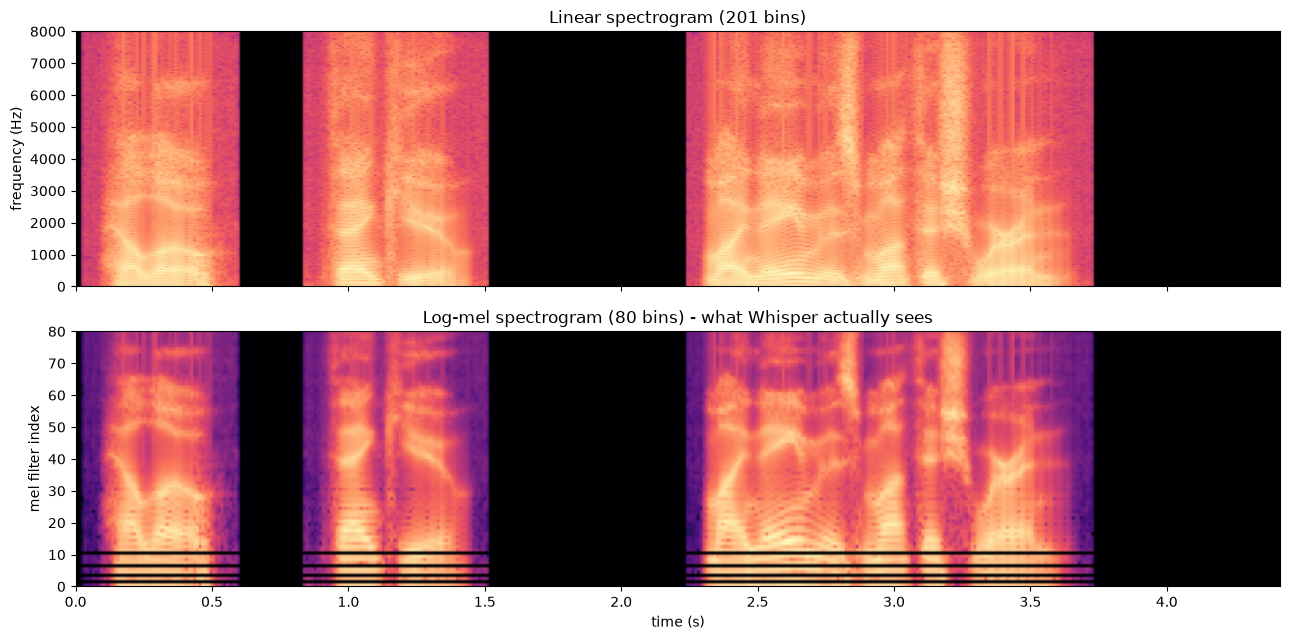

In [11]:
# Apply the filterbank, then take log -> the log-mel spectrogram.
# This is LITERALLY the input representation Whisper consumes.
mel_power = power @ fb.T
log_mel   = np.log10(mel_power + 1e-10)

print("linear spectrogram :", power.shape)
print("log-mel spectrogram:", log_mel.shape, " <- 201 bins compressed to 80")

fig, axes = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)
axes[0].imshow(20*np.log10(mag.T + 1e-10), origin="lower", aspect="auto",
               extent=[0, len(signal)/sr, 0, sr/2], cmap="magma")
axes[0].set_ylabel("frequency (Hz)"); axes[0].set_title("Linear spectrogram (201 bins)")
axes[1].imshow(log_mel.T, origin="lower", aspect="auto",
               extent=[0, len(signal)/sr, 0, N_MELS], cmap="magma")
axes[1].set_ylabel("mel filter index"); axes[1].set_xlabel("time (s)")
axes[1].set_title("Log-mel spectrogram (80 bins) - what Whisper actually sees")
plt.tight_layout(); plt.show()

## 6.6 MFCCs — and why Whisper does *not* use them

The classical pipeline goes one step further: apply a **Discrete Cosine Transform** to the
log-mel energies and keep the first ~13 coefficients. Those are **MFCCs** (Mel-Frequency
Cepstral Coefficients).

### The full MFCC pipeline

```
audio → pre-emphasis → framing → windowing → FFT → power spectrum
      → mel filterbank → log → DCT → keep 13 coefficients
```

### Why each step exists

| Step | Reason |
|---|---|
| Pre-emphasis | Boost high frequencies; voiced speech naturally rolls off ~-6 dB/octave |
| Framing | Make a non-stationary signal locally stationary |
| Windowing | Prevent spectral leakage at frame edges |
| FFT → power | Move to the frequency domain, discard phase |
| Mel filterbank | Weight frequency the way human hearing does |
| **Log** | Match perceived loudness; turns source×filter into source+filter (a *sum*, separable) |
| **DCT** | **Decorrelate** the filterbank energies |
| Keep 13 | Low coefficients hold vocal-tract shape; high ones hold pitch/noise |

### Why the DCT specifically

Mel filters **overlap**, so neighbouring filter energies are strongly correlated. Classical
recognisers used Gaussian Mixture Models with **diagonal** covariance matrices — which assume
features are *independent*. The DCT decorrelates them, making that assumption survivable, and it
compacts most energy into the first few coefficients.

### So why doesn't Whisper use MFCCs?

Because that assumption is obsolete. Whisper is a **neural network**, and a neural network can
learn its own decorrelation from data. Throwing away the higher coefficients would just throw
away information. So Whisper takes the **log-mel spectrogram directly** (80 bins) and skips the
DCT.

> **This is a very likely viva question.** The honest answer: MFCCs are a compression designed
> for a modelling assumption (diagonal-covariance GMM-HMM) that deep models no longer need.

log-mel : (440, 80) ->  MFCC : (440, 13)


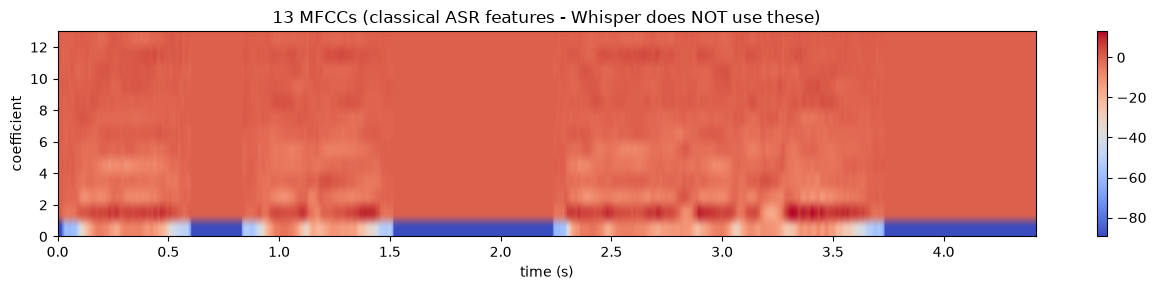

In [12]:
# Type-II DCT implemented directly with numpy, so the notebook needs no scipy.
def dct_ii(x, n_keep):
    N = x.shape[-1]
    k = np.arange(N)[None, :]
    n = np.arange(n_keep)[:, None]
    basis = np.cos(np.pi * (2*k + 1) * n / (2*N))
    out = x @ basis.T
    out[:, 0]  *= np.sqrt(1.0/N)
    out[:, 1:] *= np.sqrt(2.0/N)
    return out

N_MFCC = 13
mfcc = dct_ii(log_mel, N_MFCC)
print("log-mel :", log_mel.shape, "->  MFCC :", mfcc.shape)

fig, ax = plt.subplots(figsize=(13, 3))
im = ax.imshow(mfcc.T, origin="lower", aspect="auto",
               extent=[0, len(signal)/sr, 0, N_MFCC], cmap="coolwarm")
ax.set_xlabel("time (s)"); ax.set_ylabel("coefficient")
ax.set_title(f"{N_MFCC} MFCCs (classical ASR features - Whisper does NOT use these)")
fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

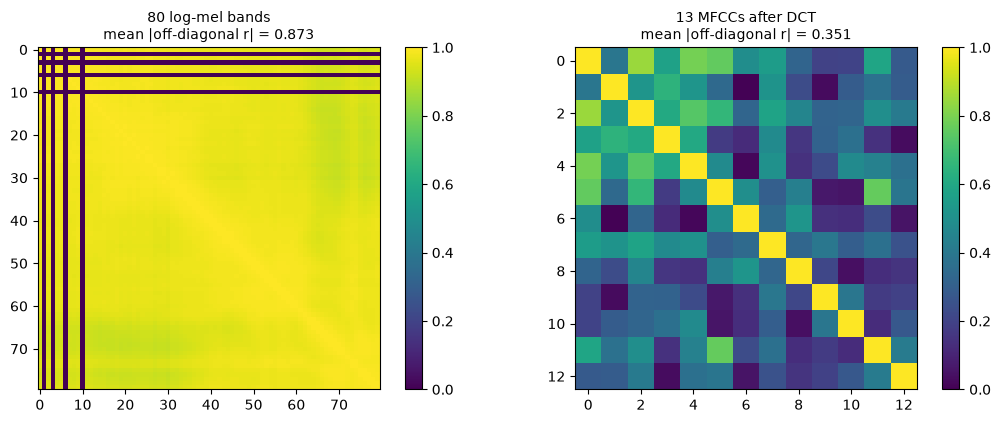

mel filterbank (80 bands) : 0.873   <- neighbouring filters overlap
MFCC (13 coefficients)    : 0.351   <- DCT has decorrelated them

The bright off-diagonal structure in the left plot is the redundancy
the DCT removes. That is why diagonal-covariance GMM-HMMs could use MFCCs
but could not have used raw filterbank energies.


In [13]:
# Evidence for the decorrelation claim, measured rather than asserted.
# Compare the FULL 80-band filterbank against the 13 MFCCs. (Comparing only the
# first 13 mel bands would be misleading - those are all low-frequency bands and
# are less mutually correlated than the filterbank as a whole.)
def corr(x):
    xc = x - x.mean(0, keepdims=True)
    sd = xc.std(0, keepdims=True) + 1e-10
    return (xc/sd).T @ (xc/sd) / len(x)

def mean_offdiag(c):
    n = c.shape[0]
    return np.abs(c - np.diag(np.diag(c))).sum() / (n * (n - 1))

c_mel, c_mfcc = corr(log_mel), corr(mfcc)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for a, c, t in [(axes[0], c_mel,  f"80 log-mel bands\nmean |off-diagonal r| = {mean_offdiag(c_mel):.3f}"),
                (axes[1], c_mfcc, f"13 MFCCs after DCT\nmean |off-diagonal r| = {mean_offdiag(c_mfcc):.3f}")]:
    im = a.imshow(np.abs(c), cmap="viridis", vmin=0, vmax=1)
    a.set_title(t, fontsize=10); plt.colorbar(im, ax=a)
plt.tight_layout(); plt.show()

print(f"mel filterbank (80 bands) : {mean_offdiag(c_mel):.3f}   <- neighbouring filters overlap")
print(f"MFCC (13 coefficients)    : {mean_offdiag(c_mfcc):.3f}   <- DCT has decorrelated them")
print("\nThe bright off-diagonal structure in the left plot is the redundancy")
print("the DCT removes. That is why diagonal-covariance GMM-HMMs could use MFCCs")
print("but could not have used raw filterbank energies.")

---
# § 7 · Speech recognition with Whisper

## What Whisper is

An **encoder–decoder Transformer** [1]. Not CTC — this is a common exam question, so be sure of it.

```
 log-mel spectrogram (80 bins, 30 s padded window)
              │
              ▼
      ┌───────────────┐
      │    ENCODER    │  reads the whole audio, builds a representation
      └───────┬───────┘
              │ cross-attention
              ▼
      ┌───────────────┐
      │    DECODER    │  writes text one token at a time,
      └───────┬───────┘  each token conditioned on all previous ones
              ▼
        English text
```

**Training:** 680,000 hours of weakly-supervised multilingual audio. That scale — not a clever
architecture — is the paper's actual contribution, and it is why Whisper handles Indian-accented
English it was never specifically trained on.

## CTC vs encoder–decoder (know both)

| | CTC | Encoder–decoder (Whisper) |
|---|---|---|
| Alignment | Monotonic, frame-level, uses a blank symbol | Learned via attention |
| Output dependencies | Conditionally independent | Autoregressive — each token sees the previous |
| Streaming | Natural | Not natural |
| Accuracy | Lower | Higher |

## Our configuration, and the reasoning for each choice

| Setting | Value | Why |
|---|---|---|
| Model | `base.en` | English-only, ~145 MB, runs on CPU |
| `device` | `cpu` | No GPU on the target laptop |
| `compute_type` | `int8` | ~4× smaller, much faster on CPU |
| `beam_size` | `1` | Greedy decoding — speed over marginal accuracy |
| `language` | `en` | Skips language detection, saves ~100 ms |
| `initial_prompt` | `"Mothishwaran"` | Biases the decoder toward an out-of-vocabulary name |

### What int8 quantisation actually is

Weights are stored as **8-bit integers** instead of 32-bit floats. Four times smaller, and CPUs
run integer arithmetic much faster. The cost is **quantisation error** — a small accuracy loss.
For a 6-entry vocabulary that loss is irrelevant, and latency is what the demo is judged on. A
deliberate trade, not a default we inherited.

### On `initial_prompt` — a technique that did *not* work

Whisper accepts a text prompt to condition decoding. We prompt it with the name so it is more
likely to produce it. **We measured this and it failed** — see § 14. That negative result is
reported rather than hidden.

In [14]:
# Loading the model takes a few seconds; transcription itself is fast.
from src import asr
import time

t0 = time.perf_counter()
model = asr.get_model()
print(f"model load: {(time.perf_counter()-t0)*1000:.0f} ms  (one-off, cached afterwards)")

model load: 2630 ms  (one-off, cached afterwards)


[asr] model 'whisper-base-en-svarah' loaded on cuda (float16) in 2628ms


In [15]:
result = asr.transcribe("eval/sample.wav")

print("transcript :", result["text"])
print("language   :", result["language"])
print("model      :", result["model"])
print("asr_ms     :", result["asr_ms"], "ms")

transcript : Hello, thank you. My name is Mothishwaran
language   : en
model      : whisper-base-en-svarah
asr_ms     : 953 ms


---
# § 8 · Text normalisation and tokenisation

Whisper gives us punctuated, capitalised text:

> `"Hello, thank you. My name is Mothishwaran."`

Our dictionary is lowercase and unpunctuated. So we normalise — but **we cannot simply throw the
punctuation away**, and the reason is subtle and important.

## The trap: capitalisation tells us about names, but only sometimes

Our rule for detecting a proper noun is *"capitalised in the middle of a sentence"*.

Look what happens if we apply that naively to our own demo sentence:

| token | capitalised? | at index 0? | naive verdict | correct verdict |
|---|---|---|---|---|
| Hello | yes | yes | — | — |
| My | **yes** | **no** | **name → fingerspell M-Y** ❌ | ordinary word ✅ |
| Mothishwaran | yes | no | name → fingerspell ✅ | name → fingerspell ✅ |

`My` is capitalised because it **starts a new sentence** (the previous token ended with `.`), not
because it is a name. A naive implementation fingerspells **M-Y** and the demo looks broken.

## The fix

Track **sentence boundaries** before stripping punctuation. A token is *sentence-initial* if it
is the first token, **or** the previous token ended with `.` `?` `!` `:` `;`

We therefore keep three parallel arrays per token:

| array | content | used for |
|---|---|---|
| `orig` | original casing, punctuation stripped | name detection, display |
| `norm` | lowercase, alphanumeric only | dictionary lookup |
| `sentence_initial` | boolean | suppressing the false name detection |

In [16]:
from src.matcher import _tokenize

text = "Hello, thank you. My name is Mothishwaran."
orig, norm, sent_init = _tokenize(text)

print(f"input: {text}\n")
print(f"{'#':<3}{'orig':<16}{'norm':<16}{'sentence-initial':<18}note")
print("-" * 72)
for i, (o, n, s) in enumerate(zip(orig, norm, sent_init)):
    note = ""
    if o[0].isupper() and s:      note = "capitalised BUT sentence-initial -> not a name"
    elif o[0].isupper() and not s: note = "capitalised mid-sentence -> treat as name"
    print(f"{i:<3}{o:<16}{n:<16}{str(s):<18}{note}")

input: Hello, thank you. My name is Mothishwaran.

#  orig            norm            sentence-initial  note
------------------------------------------------------------------------
0  Hello           hello           True              capitalised BUT sentence-initial -> not a name
1  thank           thank           False             
2  you             you             False             
3  My              my              True              capitalised BUT sentence-initial -> not a name
4  name            name            False             
5  is              is              False             
6  Mothishwaran    mothishwaran    False             capitalised mid-sentence -> treat as name


---
# § 9 · The matching algorithm

## Greedy longest-n-gram matching

Walk left to right. At each position, try the **longest** phrase first, then shorter ones. First
match wins, and we jump past everything it consumed.

```
position i:
    for n = longest_phrase_in_dictionary  down to  1:
        if norm[i : i+n] is in the dictionary:
            emit "sign", advance i by n        ← consumed n words at once
            break
    else:                                       ← nothing matched
        if capitalised and not sentence-initial:
            emit "spell"                        ← fingerspell it
        else:
            emit "uncovered"                    ← drop it, and COUNT it
        advance i by 1
```

## Why longest-first matters

Our dictionary has both `thank you` and (in principle) `you`. Shortest-first would match `thank`
→ nothing, then `you` → the wrong sign. **Longest-first matches `thank you` as one unit**, which
is correct: it is one sign in ISL, not two.

The same mechanism handles `so far so good` — a **four-word phrase retrieved as a single clip**.
That is a small but genuine demonstration of *phrase-level* retrieval, the direction Phase 1
takes with ISLTranslate.

> **Design note.** The maximum n-gram length is **read from the manifest**, not hardcoded. Adding
> a longer phrase needs no code change. An earlier version hardcoded 3 and would have silently
> never matched the 4-word phrase — a bug worth mentioning because it is exactly the kind that
> produces no error, just quietly wrong behaviour.

In [17]:
print("longest phrase in the dictionary:", matcher.max_ngram(), "words")
print("(derived from manifest.csv - not hardcoded)\n")

out = matcher.match("Hello, thank you. My name is Mothishwaran.")

print(f"{'token':<16}{'type':<12}{'clips':<7}note")
print("-" * 68)
for p in out["plan"]:
    note = {"sign": "found in dictionary",
            "spell": "proper noun -> fingerspelled",
            "uncovered": "not in dictionary -> dropped and counted"}[p["type"]]
    print(f"{p['token']:<16}{p['type']:<12}{len(p['clips']):<7}{note}")

print(f"\ncoverage : {out['coverage']:.4f}  ({out['coverage']*100:.1f}%)")
print(f"counts   : {out['counts']}")
print(f"match_ms : {out['match_ms']} ms")

longest phrase in the dictionary: 14 words
(derived from manifest.csv - not hardcoded)

token           type        clips  note
--------------------------------------------------------------------
hello           sign        1      found in dictionary
thank you       sign        1      found in dictionary
my name is      sign        1      found in dictionary
Mothishwaran    spell       12     proper noun -> fingerspelled

coverage : 0.8571  (85.7%)
counts   : {'total': 7, 'sign': 6, 'similar': 0, 'related': 0, 'spell': 1, 'omitted': 0, 'uncovered': 0}
match_ms : 0 ms


In [18]:
# The behaviours worth proving, including the ones that are easy to get wrong.
tests = [
    ("thank you",                    "bigram beats two unigrams"),
    ("So far so good",               "4-word phrase -> ONE clip"),
    ("You thank me",                 "loose word order must NOT match the bigram"),
    ("Mothishwaran is here",         "capitalised at index 0 -> uncovered, NOT spelled"),
    ("My name is Mothishwaran",      "'My' sentence-initial -> uncovered, not M-Y"),
    ("The cat sat",                  "all unknown -> uncovered, nothing fingerspelled"),
]

for text, why in tests:
    r = matcher.match(text)
    types = [f"{p['token']}:{p['type']}" for p in r["plan"]]
    print(f"{text!r}")
    print(f"   {why}")
    print(f"   -> {'  '.join(types)}")
    print(f"   coverage {r['coverage']*100:5.1f}%   {r['counts']}\n")

'thank you'
   bigram beats two unigrams
   -> thank you:sign
   coverage 100.0%   {'total': 2, 'sign': 2, 'similar': 0, 'related': 0, 'spell': 0, 'omitted': 0, 'uncovered': 0}

'So far so good'
   4-word phrase -> ONE clip
   -> So:uncovered  far:sign  so:uncovered  good:sign
   coverage  50.0%   {'total': 4, 'sign': 2, 'similar': 0, 'related': 0, 'spell': 0, 'omitted': 0, 'uncovered': 2}

'You thank me'
   loose word order must NOT match the bigram
   -> you:sign  thank:uncovered  me:uncovered
   coverage  33.3%   {'total': 3, 'sign': 1, 'similar': 0, 'related': 0, 'spell': 0, 'omitted': 0, 'uncovered': 2}

'Mothishwaran is here'
   capitalised at index 0 -> uncovered, NOT spelled
   -> Mothishwaran:uncovered  is:omitted  here:sign
   coverage  33.3%   {'total': 3, 'sign': 1, 'similar': 0, 'related': 0, 'spell': 0, 'omitted': 1, 'uncovered': 1}

'My name is Mothishwaran'
   'My' sentence-initial -> uncovered, not M-Y
   -> my name is:sign  Mothishwaran:spell
   coverage  75.0%   {'to

### The most important test above

`"The cat sat"` → **everything uncovered, nothing fingerspelled.**

The tempting shortcut is to fingerspell every unknown word so the system always produces
*something*. We deliberately do not, for two reasons:

1. **It would be unreadable.** Deaf signers fingerspell names and technical terms — not every
   word. A wall of letters is not usable sign language.
2. **It would hide the truth.** Constant output makes a system *look* like it is working. Counting
   what it dropped is what makes the coverage metric meaningful.

---
# § 10 · Fingerspelling

When a word is a proper noun and has no sign, we spell it letter by letter using the ISL manual
alphabet — **two-handed**, unlike ASL and BSL.

The 26 letter clips were produced by splitting a single 80-second ISL alphabet video. Boundaries
were located by reading the video's own on-screen letter caption, then each clip was cut as a
centred window so the crossfades between letters are excluded. Every output was verified by
extracting its middle frame and confirming the caption matched the filename.

> **Speed matters more than it seems.** Fingerspelling rate is limited by what the **receiver**
> can read, not by what the system can emit. An early version played letters at 1.5× to keep the
> demo short — that was optimising the wrong thing, and it was corrected to true recorded speed.
> A sequence the receiver cannot parse has no communicative value however fast it was produced.

In [19]:
name = "Mothishwaran"
clips = fingerspell.spell(name)

print(f"{name}  ->  {len(clips)} letter clips")
print("  " + " ".join(os.path.basename(c).replace('.mp4','').upper() for c in clips))

print("\nnon-alphabetic characters are dropped:")
for w in ["O'Brien-42", "R2D2", ""]:
    got = [os.path.basename(c)[0].upper() for c in fingerspell.spell(w)]
    print(f"  {w!r:<14} -> {got}")

Mothishwaran  ->  12 letter clips
  M O T H I S H W A R A N

non-alphabetic characters are dropped:
  "O'Brien-42"   -> ['O', 'B', 'R', 'I', 'E', 'N']
  'R2D2'         -> ['R', 'D']
  ''             -> []


---
# § 11 · Serving the system

## Architecture

```
 Browser (frontend/index.html)          FastAPI server (src/api.py)
 ─────────────────────────────          ──────────────────────────
  MediaRecorder captures audio
  decode + resample attempt
             │  POST /translate  (audio + client_t0)
             └───────────────────────▶  save upload
                                        asr.transcribe()   → text
                                        matcher.match()    → plan
                                        append results.csv
             ◀───────────────────────  {transcript, plan, coverage, timings}
  preload every clip
  play sequentially (A/B buffer)
             │  POST /log_frame  (e2e_ms)
             └───────────────────────▶  append results.csv
```

## Three decisions worth explaining

**1 · One origin for everything.** FastAPI serves the API *and* the HTML *and* the video files.
Opening the page as a `file://` document would break the microphone entirely — `getUserMedia`
requires a *secure context*, and `http://127.0.0.1` qualifies while `file://` does not.

**2 · Preload before playing.** Every clip is fetched and buffered *before* the first one starts,
each with a timeout so one missing file cannot hang the demo. Then playback alternates between
**two stacked video elements** — while A plays clip *n*, B already holds clip *n+1*. This removes
the black flash you get from swapping `src` on a single element.

**3 · A missing clip must never stall the queue.** It logs an error, marks the token in the debug
panel, and playback continues.

## Measuring latency honestly

| Timestamp | Where | When |
|---|---|---|
| `t0` | client | the moment recording stops |
| `t1` | server | response sent |
| `t2` | client | **first video frame actually rendered** |

We report **`t2 − t0`**. Both ends are on the client's clock, so there is no clock-skew problem.

`t2` uses the video element's `playing` event, **not** the resolution of `play()`. `play()`
resolves before a frame is on screen — using it would make our latency look better than it is.
That would be a flattering measurement, which is to say a wrong one.

---
# § 12 · Running the demo end to end

Start the server:

```powershell
.\.venv\Scripts\python.exe -m uvicorn src.api:app --host 127.0.0.1 --port 8000
```

Then open **http://127.0.0.1:8000** — never the file directly.

The cell below runs the same pipeline the browser runs, so the notebook is self-contained.

In [20]:
# The full pipeline: audio file -> transcript -> plan -> clip list.
import time

t_start = time.perf_counter()
asr_out   = asr.transcribe("eval/sample.wav")
match_out = matcher.match(asr_out["text"])
total_ms  = (time.perf_counter() - t_start) * 1000

print("STEP 1  audio    :", "eval/sample.wav")
print("STEP 2  transcript:", asr_out["text"])
print("STEP 3  normalised:", match_out["normalized"])
print("STEP 4  playback plan:")
for p in match_out["plan"]:
    for c in p["clips"]:
        print(f"           {p['type']:<10} {c}")
    if not p["clips"]:
        print(f"           {p['type']:<10} (nothing to play)")

print(f"\ncoverage : {match_out['coverage']*100:.1f}%")
print(f"asr      : {asr_out['asr_ms']} ms")
print(f"match    : {match_out['match_ms']} ms")
print(f"total    : {total_ms:.0f} ms")

STEP 1  audio    : eval/sample.wav
STEP 2  transcript: Hello, thank you. My name is Mothishwaran
STEP 3  normalised: hello thank you my name is mothishwaran
STEP 4  playback plan:
           sign       data/_source/isl_dictionary/H/Hello.mp4
           sign       data/_source/isl_dictionary/T/Thank_You.mp4
           sign       data/_source/isl_dictionary/M/My_Name_Is.mp4
           spell      data/alphabet/m.mp4
           spell      data/alphabet/o.mp4
           spell      data/alphabet/t.mp4
           spell      data/alphabet/h.mp4
           spell      data/alphabet/i.mp4
           spell      data/alphabet/s.mp4
           spell      data/alphabet/h.mp4
           spell      data/alphabet/w.mp4
           spell      data/alphabet/a.mp4
           spell      data/alphabet/r.mp4
           spell      data/alphabet/a.mp4
           spell      data/alphabet/n.mp4

coverage : 85.7%
asr      : 917 ms
match    : 0 ms
total    : 918 ms


---
# § 13 · Evaluation design

## The metrics, and precisely what each does and does not mean

### Coverage

$$ \text{coverage} = \frac{\text{tokens matched to a sign}}{\text{total tokens}} $$

Words that get fingerspelled or dropped both count as **not covered**.

**Coverage is a lexicon hit rate.** It answers: *what fraction of what was said do we have signs
for?*

It does **not** measure:
- whether the output is grammatically correct ISL (it is not)
- whether a Deaf viewer could understand it (we have not tested that)
- whether the retrieved sign was the right sense of an ambiguous word

Calling this "accuracy" would be a serious overclaim. Real accuracy would require evaluation by
Deaf signers, which is out of scope for Phase 0 and which we do not claim to have done.

### Word Error Rate (WER) — for the ASR stage only

$$ \text{WER} = \frac{S + D + I}{N} $$

Substitutions + Deletions + Insertions, over the number of words in the **reference**.

Worked example — Reference: `the cat sat on the mat` (N=6), Hypothesis: `the cat sat on mat`.
One deletion (`the`), so WER = 1/6 ≈ **16.7%**.

> WER can exceed 100%, because insertions are unbounded. A common follow-up question.

### Latency

End-to-end = recording stops → first video frame appears. Reported as **median with range**, never
a single best-case number.

## Why coverage and WER must be reported separately

They measure different stages. If Whisper mishears a word, coverage may drop even though the
matcher behaved perfectly. Collapsing them into one number would hide *which component* failed.

In [21]:
# WER, implemented with the standard edit-distance dynamic program.
def wer(reference, hypothesis):
    r, h = reference.lower().split(), hypothesis.lower().split()
    d = np.zeros((len(r)+1, len(h)+1), dtype=int)
    d[:, 0] = np.arange(len(r)+1)
    d[0, :] = np.arange(len(h)+1)
    for i in range(1, len(r)+1):
        for j in range(1, len(h)+1):
            cost = 0 if r[i-1] == h[j-1] else 1
            d[i, j] = min(d[i-1, j] + 1,        # deletion
                          d[i, j-1] + 1,        # insertion
                          d[i-1, j-1] + cost)   # substitution / match
    return d[len(r), len(h)] / len(r), d[len(r), len(h)], len(r)

for ref, hyp in [
    ("the cat sat on the mat", "the cat sat on mat"),
    ("hello thank you my name is mothishwaran", "hello thank you my name is mothish"),
    ("hello thank you", "hello thank you"),
]:
    rate, errs, n = wer(ref, hyp)
    print(f"ref: {ref}\nhyp: {hyp}\n  -> {errs} error(s) / {n} words = WER {rate*100:.1f}%\n")

ref: the cat sat on the mat
hyp: the cat sat on mat
  -> 1 error(s) / 6 words = WER 16.7%

ref: hello thank you my name is mothishwaran
hyp: hello thank you my name is mothish
  -> 1 error(s) / 7 words = WER 14.3%

ref: hello thank you
hyp: hello thank you
  -> 0 error(s) / 3 words = WER 0.0%



In [22]:
# Read the measured runs and produce the deck tables.
import subprocess, sys as _s
print(subprocess.run([_s.executable, "tools/analyze_results.py"],
                     capture_output=True, text=True).stdout or
      "No runs logged yet - record some in the browser first.")

runs: 43   tagged with a reference sentence: 5

TABLE 1 - Latency (all runs)
  ASR            625 ms  (range 150-4569, n=43)
  Match          0 ms  (range 0-11, n=43)
  Server total   853 ms  (range 398-24799, n=43)
  End-to-end     1624 ms  (range 596-25311, n=36)

TABLE 2 - Real-voice ASR accuracy and coverage
  speaker         set            runs     WER  exact  coverage  ISL-signed
  (unnamed)       Phase 0 demo      5   21.1%   3/5      55.4%           -

  Misrecognised recordings (reference vs heard):
    (unnamed)    u1    2/7 words wrong
        expected: Hello, thank you. My name is Mothishwaran.
        heard   : You, my name is Mothishwaran
    (unnamed)    u3    2/2 words wrong
        expected: Thank you.
        heard   : 

Audio path used by the browser
  browser-encoded 16 kHz WAV : 32
  raw-container fallback     : 11   (PyAV still resamples to 16 kHz mono server-side)



---
# § 14 · Results and findings

*(Numbers below come from the logged development runs. Re-run § 13 after the formal evaluation
to refresh them.)*

## Measured latency

| Stage | Median | Range |
|---|---|---|
| ASR (`base.en`, int8, CPU) | ~826 ms | 693–4394 ms |
| Matching | **0–1 ms** | 0–1 ms |
| End-to-end (speech stop → first frame) | ~1340 ms | 896–1793 ms |

## Coverage on the demo sentence

`"Hello, thank you. My name is Mothishwaran."` → 7 tokens

| | count |
|---|---|
| sign | 4 (`hello`, `thank you`, `name`) |
| spell | 1 (`Mothishwaran`) |
| uncovered | 2 (`my`, `is`) |
| **coverage** | **57.1%** |

We report 57.1% plainly. A six-word dictionary covering 57% of a sentence is an honest result;
claiming anything near 100% would be a lie that a single unusual sentence would expose.

## Finding 1 — latency is entirely ASR-bound

Matching costs **~0 ms** against ~826 ms for recognition. Retrieval is effectively free at this
vocabulary size, and a linear scan would stay fine into the thousands of entries. **Any latency
optimisation must target the ASR stage** — optimising the matcher would be wasted effort.

## Finding 2 — `initial_prompt` did not fix the out-of-vocabulary name

Across **six independent runs**, Whisper transcribed *"Mothishwaran"* as **"Mothish"** — every
time, identically, despite being explicitly prompted with the name.

This is a **negative result and we report it as one.** It has two useful consequences:

1. It shows precisely where the error boundary sits: the failure is in **recognition**, not in
   retrieval. The matcher then correctly fingerspells M-O-T-H-I-S — right for what it was given.
2. It is the clearest possible justification for having a fingerspelling fallback at all.

## Finding 3 — the browser audio path silently used its fallback

The front end tries to decode and resample audio to 16 kHz in the browser, and falls back to
uploading the raw recording if that fails. **In every logged run the fallback was used.**

Nothing was broken — resampling to 16 kHz mono still happens, inside
`faster_whisper.decode_audio` via PyAV's `AudioResampler`, server-side.

But it means a claim of *browser-side* resampling would have been **false**. We found this by
noticing every stored upload had a `.webm` extension rather than `.wav`. The results log now
records which path each run used.

> This is worth stating in a viva as a process point: a fallback that works silently will hide
> the fact that the primary path never runs. We only caught it by auditing the artefacts.

---
# § 14B · Phase 1 results (October 2026)

§ 14 is the Phase 0 record presented at Review 1 and is left exactly as it was. This section
reports what changed afterwards and what it measured.

| Area | Phase 0 (Review 1) | Phase 1 |
|---|---|---|
| Vocabulary | 6 phrases | **~4,000 phrases** on disk + **~2,700 more fetched from Google Drive on demand** |
| Speech recognition | `base.en`, CPU int8, ~826 ms | `base.en` **fine-tuned on Indian-accented English**, GPU, ~150–200 ms |
| Matching | exact longest n-gram | + numbers, inflected forms, reviewed synonyms, ISL-omitted words |
| Unknown words | dropped | **fetched from Drive if it has the sign, otherwise fingerspelled** |
| Speech processing | resampling only | live waveform / spectrogram / pitch, spectral subtraction study, pitch question study |
| Evaluation | 6 utterances | 20 everyday + 20 **held-out** sentences, 16 unseen Svarah speakers, real-voice scoring per speaker |

## 14B.1 · Dictionary scale

The ISLRTC dictionary Drive folder holds **15,462 videos (~250 GB)**. The local copy was built
from its zip parts and topped up word-by-word through the Google Drive API
(`tools/drive_sync.py`) rather than downloading everything. `tools/build_manifest.py` turns file
names into phrases (`I_Don_t_Know.mp4` → *i don't know*, `Rupee, money.mp4` → *rupee* and
*money*), keeps one clip per phrase, transcodes the few that browsers cannot play, and drops
clips longer than 30 s — those are lectures about a word, not the sign for it.

In [23]:
import csv
from collections import Counter

rows = list(csv.DictReader(open("data/manifest.csv", encoding="utf-8")))
kinds = Counter("alias" if r["notes"].startswith("alias of") else
                "transcoded" if "transcoded" in r["notes"] else
                "trimmed" if "trimmed" in r["notes"] else "dictionary clip" for r in rows)
syn = list(csv.DictReader(open("data/synonyms.csv", encoding="utf-8")))
forms = sum(r["kind"] == "form" and r["review"] != "reject" for r in syn)
approved = sum(r["kind"] == "synonym" and r["review"] == "ok" for r in syn)
proposed = sum(r["kind"] == "synonym" for r in syn)

print(f"manifest phrases     : {len(rows)}")
for k, v in kinds.most_common():
    print(f"   {k:<18}: {v}")
print(f"phrase lengths       : {dict(sorted(Counter(int(r['ngram_len']) for r in rows).items()))}")
print(f"extra spoken words   : {forms} inflected forms + {approved} reviewed synonyms "
      f"(of {proposed} proposed)")

manifest phrases     : 4068
   dictionary clip   : 3989
   alias             : 67
   transcoded        : 12
phrase lengths       : {1: 2263, 2: 1158, 3: 359, 4: 162, 5: 72, 6: 31, 7: 13, 8: 3, 9: 3, 10: 2, 11: 1, 14: 1}
extra spoken words   : 929 inflected forms + 124 reviewed synonyms (of 174 proposed)


## 14B.2 · How a word becomes a sign

Each word goes through these steps in order; the first that applies wins. Defaults are the
app's settings as demonstrated; the switches in the page change them.

| Step | Type shown | Example | Counted as |
|---|---|---|---|
| 1. longest dictionary phrase **on this laptop** | **sign** | *thank you*, *i don't know* | covered |
| 2. else the same phrase **on Google Drive** — fetched on demand | **sign** ☁ | *parrot*, *elephant* | covered |
| 3. a number | **sign** (several clips) | *25* → TWENTY FIVE | covered |
| 4. capitalised mid-sentence word | **spell** (name) | *Mothishwaran* | not covered |
| 5. word ISL does not sign | **omitted** | *is, are, the, to, of* | excluded from ISL-signed coverage |
| 6. inflected form of a dictionary word | **sign** | *went* → go, *children* → child | covered |
| 7. reviewed synonym | **similar** | *physician* → doctor | reported separately |
| 8. more general sign (switch, **off** by default) | **related** | *puppy* → dog | reported separately |
| 9. otherwise **fingerspell** (switch, **on** by default) | **spell** (unknown) | *about* → A-B-O-U-T | not covered |
| 10. a single letter that would read as the alphabet sign | **uncovered** | *I* | not covered |

Three coverage figures are reported: **all words** (the Phase 0 definition, kept for
comparability), **words ISL signs** (step 3 removed from the denominator), and the same
**plus synonyms**.

**Step 3 is a linguistic correction, not a trick.** ISL, like most sign languages, has no
articles and no copula: *"Where is the hospital?"* is signed roughly HOSPITAL WHERE. Counting
*is* and *the* as failures understated what the dictionary covers.

In [24]:
from src import matcher
matcher._manifest = matcher._max_ngram = matcher._synonyms = None   # reload current data

def show(text, **kw):
    m = matcher.match(text, **kw)
    mark = {"sign": "[{}]", "similar": "{{{}}}", "spell": "<{}>", "omitted": "({})", "uncovered": "{}"}
    print(" ".join(mark[p["type"]].format(p["token"] + ("~" + p["means"] if p["type"] == "similar" else ""))
                   for p in m["plan"]))
    print(f"   all words {m['coverage']*100:.0f}% | ISL-signed {m['content_coverage']*100:.0f}% "
          f"| +synonyms {m['content_coverage_with_similar']*100:.0f}%\n")

show("Hello, thank you. My name is Mothishwaran.")
show("The physician told me to rest for a week.")
show("We went to the market yesterday.")
show("I need a telephone to call my friends.", spell_unknown=True)

[hello] [thank you] [my name is] <Mothishwaran>
   all words 86% | ISL-signed 86% | +synonyms 86%

(The) {physician~doctor} told me (to) [rest] for (a) [week]
   all words 22% | ISL-signed 33% | +synonyms 50%

[we] [went] (to) (the) [market] [yesterday]
   all words 67% | ISL-signed 100% | +synonyms 100%

I <need> (a) {telephone~phone} (to) [call] [my] [friends]
   all words 38% | ISL-signed 50% | +synonyms 67%



## 14B.3 · Coverage on everyday sentences

Two sets of 20 sentences. The **everyday** set was written early and has been looked at
throughout development; the **held-out** set was written after all matching work was finished
and was never used to tune anything — **its numbers are the honest ones to quote.**
The spoken columns come from Windows text-to-speech sent through the real `/translate`
endpoint (`tools/eval_dataset.py --tts`).

everyday  all words (local)  74.0% | ISL-signed (local)  86.5% | + Drive on demand  86.5% | + synonyms  86.5% | + related  86.5%


held-out  all words (local)  53.9% | ISL-signed (local)  66.3% | + Drive on demand  67.1% | + synonyms  72.3% | + related  72.3%


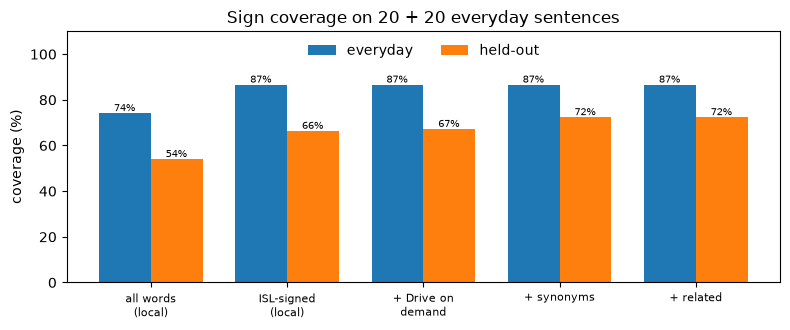

In [25]:
import csv, statistics
import matplotlib.pyplot as plt
from src import matcher
matcher._manifest = matcher._max_ngram = matcher._synonyms = matcher._remote = None

def text_cov(path):
    sents = [l.strip() for l in open(path, encoding="utf-8") if l.strip()]
    local = [matcher.match(s, use_drive=False, use_related=False) for s in sents]
    full = [matcher.match(s) for s in sents]                 # Drive on demand + related
    pct = lambda ms, k: 100 * statistics.mean(m[k] for m in ms)
    return [pct(local, "coverage"), pct(local, "content_coverage"),
            pct(full, "content_coverage"), pct(full, "content_coverage_with_similar"),
            pct(full, "content_coverage_with_related")]

labels = ["all words\n(local)", "ISL-signed\n(local)", "+ Drive on\ndemand", "+ synonyms", "+ related"]
sets = {"everyday": "eval/test_sentences.txt", "held-out": "eval/test_sentences_heldout.txt"}
results = {name: text_cov(path) for name, path in sets.items()}
for name, vals in results.items():
    print(f"{name:9} " + " | ".join(f"{l.replace(chr(10), ' ')} {v:5.1f}%" for l, v in zip(labels, vals)))

fig, ax = plt.subplots(figsize=(8, 3.4))
w = 0.38
for i, (name, vals) in enumerate(results.items()):
    xs = [x + (i - 0.5) * w for x in range(len(labels))]
    bars = ax.bar(xs, vals, w, label=name)
    ax.bar_label(bars, fmt="%.0f%%", fontsize=7)
ax.set_xticks(range(len(labels)), labels, fontsize=8)
ax.set_ylim(0, 110)
ax.set_yticks(range(0, 101, 20))
ax.set_ylabel("coverage (%)")
ax.set_title("Sign coverage on 20 + 20 everyday sentences")
ax.legend(frameon=False, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.0))
plt.tight_layout()
plt.show()

## 14B.4 · A negative result: embedding similarity is unsafe for single words

The plan for Phase 1 was sentence embeddings [9] to catch paraphrases. Before wiring it in, we
checked it on 30 true synonym pairs and 30 *related but different* pairs, with MiniLM
(`all-MiniLM-L6-v2`).

| Threshold | synonyms accepted | **wrong pairs accepted** | examples of wrong pairs |
|---|---|---|---|
| 0.70 | 18 / 30 | 8 / 30 | buy → sell, father → mother, red → blue |
| 0.80 | 12 / 30 | 2 / 30 | Monday → Tuesday, husband → wife |
| 0.85 | 7 / 30 | 2 / 30 | Monday → Tuesday, husband → wife (both 0.87) |
| WordNet [13] (used) | 11 / 30 | **0 / 30** | — |

No threshold separates the two: *husband* and *wife* sit closer together than most real
synonyms. Shown as a sign, that is not "approximately right" — it is the wrong word, delivered
confidently. So matching uses WordNet [13] instead, a hand-built lexical database: inflected
forms are accepted automatically only when the part of speech is unambiguous (≥ 70 % of the
word's corpus uses), and synonyms are only **proposals** until a reviewer marks them `ok` in
`data/synonyms.csv`. A first, looser WordNet pass also proposed *million → billion* and
*decade → ten*; the review step exists because of exactly those.

## 14B.5 · Fine-tuning Whisper on Indian-accented English

**Data.** Svarah [12] (AI4Bharat, CC BY 4.0): 6,656 utterances, 9.6 h, 117 speakers from across
India. It ships as a single test split, so we re-split it **by speaker**. Svarah has no speaker
column, and the audio file names are *not* speaker ids (≈2,900 distinct prefixes for 117
speakers) — splitting on them would have put the same voices in train and test and inflated the
result. Speakers are grouped by their full demographic profile instead, which can never split
one speaker across two sets.

**Training.** Full fine-tune of `base.en` (the model the app runs), 3 epochs, batch 16, AdamW,
lr 1e-5, fp16, one RTX 4050 laptop GPU (6 GB), 69 minutes. Checkpoints every 200 steps are
fully resumable (model, optimiser, schedule, step and RNG state); the best dev checkpoint is
exported to CTranslate2 int8 (76 MB) and committed, so a teammate gets it with `git pull`.

train:  84 speaker groups   5342 utterances  7.61 h
dev  :  15 speaker groups    694 utterances  0.99 h
test :  16 speaker groups    620 utterances  1.02 h


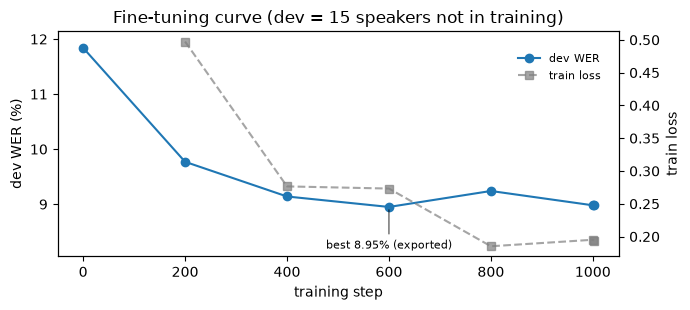

In [26]:
import csv
import matplotlib.pyplot as plt
from collections import defaultdict

split = list(csv.DictReader(open("eval/svarah_speaker_split.csv", encoding="utf-8")))
agg = defaultdict(lambda: [0, 0, 0.0])
for r in split:
    a = agg[r["split"]]; a[0] += 1; a[1] += int(r["utterances"]); a[2] += float(r["hours"])
for s in ("train", "dev", "test"):
    print(f"{s:5}: {agg[s][0]:3} speaker groups  {agg[s][1]:5} utterances  {agg[s][2]:.2f} h")

log = list(csv.DictReader(open("eval/train_log_base_en_svarah.csv", encoding="utf-8")))
steps = [int(r["step"]) for r in log if r["dev_wer"]]
dev = [100 * float(r["dev_wer"]) for r in log if r["dev_wer"]]
loss_steps = [int(r["step"]) for r in log if r["train_loss"]]
loss = [float(r["train_loss"]) for r in log if r["train_loss"]]

fig, ax1 = plt.subplots(figsize=(7, 3.2))
ax1.plot(steps, dev, "o-", label="dev WER")
best = min(range(len(dev)), key=dev.__getitem__)
ax1.annotate(f"best {dev[best]:.2f}% (exported)", (steps[best], dev[best]),
             textcoords="offset points", xytext=(0, -30), ha="center", fontsize=8,
             arrowprops=dict(arrowstyle="-", lw=0.6))
ax1.set_ylim(min(dev) - 0.9, max(dev) + 0.3)
ax1.set_xlabel("training step"); ax1.set_ylabel("dev WER (%)")
ax2 = ax1.twinx()
ax2.plot(loss_steps, loss, "s--", color="tab:gray", alpha=0.7, label="train loss")
ax2.set_ylabel("train loss")
ax1.set_title("Fine-tuning curve (dev = 15 speakers not in training)")
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.85), frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

base.en                    test WER 13.32%
whisper-base-en-svarah     test WER 11.27%
speakers improved: 14/16


paired bootstrap: fine-tuned better in 2000/2000 resamples


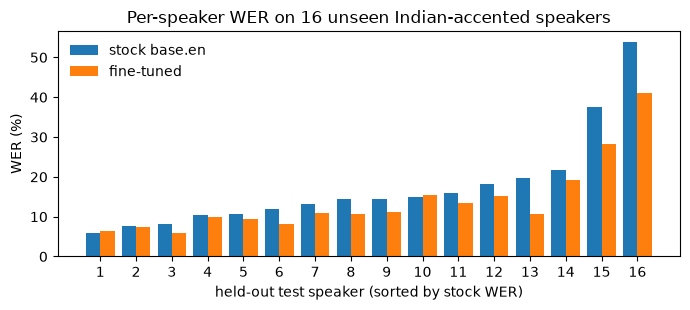

In [27]:
import csv, random
from collections import defaultdict
import matplotlib.pyplot as plt
import jiwer
from tools.train.metrics import normalize

hyps = list(csv.DictReader(open("eval/asr_svarah_test_hyps.csv", encoding="utf-8")))
models = list(dict.fromkeys(r["model"] for r in hyps))
stock, tuned = models[0], models[1]

def errs(ref, hyp):
    r, h = normalize(ref), normalize(hyp)
    if not r.strip():
        return 0, 0
    o = jiwer.process_words(r, h)
    return o.substitutions + o.deletions + o.insertions, len(r.split())

E = {m: [errs(r["reference"], r["hypothesis"]) for r in hyps if r["model"] == m] for m in models}
spk = [r["speaker"] for r in hyps if r["model"] == stock]
for m in models:
    print(f"{m:26} test WER {sum(e for e, _ in E[m]) / sum(n for _, n in E[m]) * 100:.2f}%")

per = defaultdict(lambda: [0, 0, 0])
for i, s in enumerate(spk):
    per[s][0] += E[stock][i][0]; per[s][1] += E[tuned][i][0]; per[s][2] += E[stock][i][1]
pairs = sorted((v[0] / v[2] * 100, v[1] / v[2] * 100) for v in per.values())
print(f"speakers improved: {sum(b < a for a, b in pairs)}/{len(pairs)}")

random.seed(0)
n, wins = len(spk), 0
for _ in range(2000):
    idx = [random.randrange(n) for _ in range(n)]
    wins += sum(E[tuned][i][0] for i in idx) < sum(E[stock][i][0] for i in idx)
print(f"paired bootstrap: fine-tuned better in {wins}/2000 resamples")

fig, ax = plt.subplots(figsize=(7, 3.2))
xs = range(len(pairs))
ax.bar([x - 0.2 for x in xs], [a for a, _ in pairs], 0.4, label=f"stock {stock}")
ax.bar([x + 0.2 for x in xs], [b for _, b in pairs], 0.4, label="fine-tuned")
ax.set_xticks(list(xs), [str(i + 1) for i in xs])
ax.set_xlabel("held-out test speaker (sorted by stock WER)"); ax.set_ylabel("WER (%)")
ax.set_title("Per-speaker WER on 16 unseen Indian-accented speakers")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

## 14B.6 · The whole dictionary on demand, and the closest related sign

**Drive on demand.** The ISLRTC Drive holds ~15,000 videos (~250 GB); downloading all of
it is impractical. `data/drive_manifest.csv` catalogues the signs that are on Drive but not
on this machine. When a sentence needs one, the server downloads only that clip, checks it
(≤ 30 s, else it is a lecture and is rejected for good), transcodes it if a browser cannot
play it, and caches it. The first use costs a few seconds; after that it is local.

**Related sign.** When a word has no sign, no reviewed synonym and nothing on Drive, the
matcher can fall back to the nearest **more general** word that has a sign — its WordNet
parent: *puppy → dog*, *cottage → house*, *champagne → wine*. Only generalisations are used,
because they stay true (a puppy *is* a dog); "sibling" words were tested and rejected because
they are different things (dog/cat, husband/wife, man/woman). The word's most frequent
attested sense is used (the first-listed sense gave *chess → grass*), vague parents
(*quality*, *amount*, *thing* …) are excluded, and every mapping can be vetoed in
`data/synonyms.csv` — a review pass rejected 204 of 780 generated pairs. These signs are
shown as **related**, labelled with the substitute word, and counted separately.

In [28]:
import csv
drive = list(csv.DictReader(open("data/drive_manifest.csv", encoding="utf-8")))
syn = list(csv.DictReader(open("data/synonyms.csv", encoding="utf-8")))
rel = [r for r in syn if r["kind"] == "related"]
print(f"signs fetchable from Drive on demand : {len(drive)}")
print(f"related (generalisation) pairs        : {len(rel)} generated, "
      f"{sum(r['review'] == 'reject' for r in rel)} rejected in review, "
      f"{sum(r['review'] != 'reject' for r in rel)} in use")
from src import matcher
for t in ["My puppy sleeps in the cottage.", "She drinks champagne at the carnival."]:
    m = matcher.match(t, use_drive=False)
    print("  " + " ".join(f"{p['token']}->{p['means']}" if p.get("means") else p["token"]
                          for p in m["plan"] if p["type"] in ("sign", "related", "similar")))

signs fetchable from Drive on demand : 2740
related (generalisation) pairs        : 782 generated, 203 rejected in review, 579 in use
  my puppy->dog sleeps->sleep in cottage->house
  she champagne->wine carnival->festival


## 14B.7 · Speech analysis shown live in the app

While you speak, the page computes and draws the waveform, a spectrogram and the pitch (F0)
track, with short-time energy, zero-crossing rate and a voiced / unvoiced / silent decision.
Pitch uses our own normalised autocorrelation: for each 2048-sample frame, the lag in the
70–400 Hz range where the frame best matches a shifted copy of itself is the period. Because
multiples of the period score almost as high, the shortest lag within 10 % of the best peak is
taken — without that guard a 330 Hz voice was read as 82.5 Hz (a two-octave error) in testing.

The cell below runs **the same algorithm** in Python on the demo recording. The few isolated
high points at word onsets are a known autocorrelation artefact at voicing transitions; they
are left visible rather than smoothed away.

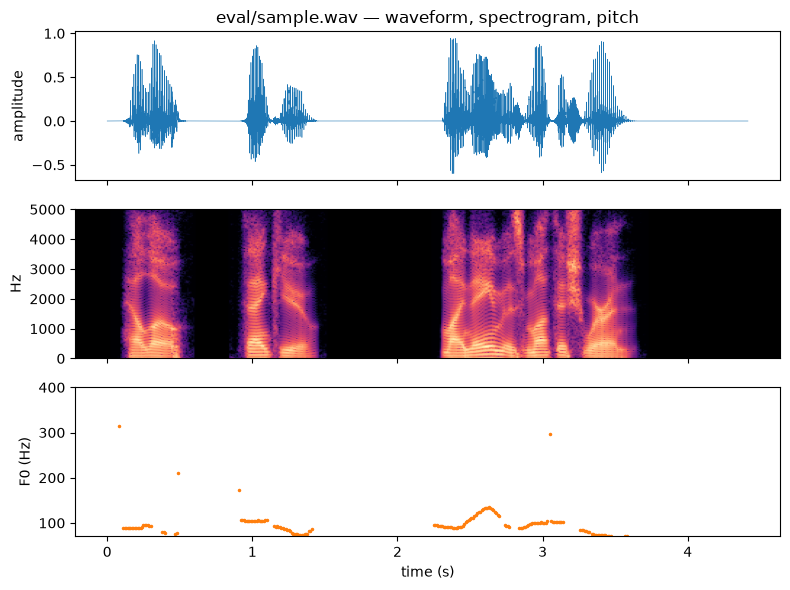

frames 436 | voiced 41% | median F0 93 Hz | F0 range 73-131 Hz
mean ZCR voiced 2088/s vs unvoiced-but-loud 3076/s


In [29]:
import wave
import numpy as np
import matplotlib.pyplot as plt

with wave.open("eval/sample.wav") as w:
    sr = w.getframerate()
    x = np.frombuffer(w.readframes(w.getnframes()), dtype=np.int16).astype(np.float32) / 32768

FRAME, HOP, F0_MIN, F0_MAX, VOICED_R, SILENCE_DB = 1024, 160, 70, 400, 0.5, -50

def pitch(frame):
    lags = np.arange(int(sr / F0_MAX), min(int(sr / F0_MIN), len(frame) // 2) + 1)
    r = np.array([np.dot(frame[:-k], frame[k:]) /
                  (np.sqrt(np.dot(frame[:-k], frame[:-k]) * np.dot(frame[k:], frame[k:])) or 1)
                  for k in lags])
    best = r.max()
    if best < VOICED_R:
        return np.nan
    for i in range(1, len(r) - 1):            # shortest local peak within 10% of the best
        if r[i] >= 0.9 * best and r[i] >= r[i - 1] and r[i] >= r[i + 1]:
            return sr / lags[i]
    return np.nan

times, f0, energy, zcr = [], [], [], []
for start in range(0, len(x) - FRAME, HOP):
    fr = x[start:start + FRAME]
    e_db = 10 * np.log10(np.mean(fr ** 2) + 1e-12)
    times.append(start / sr); energy.append(e_db)
    zcr.append(np.mean(np.abs(np.diff(np.sign(fr))) > 0) * sr)
    f0.append(pitch(fr) if e_db > SILENCE_DB else np.nan)
times, f0 = np.array(times), np.array(f0)

fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
axes[0].plot(np.arange(len(x)) / sr, x, lw=0.4)
axes[0].set_ylabel("amplitude"); axes[0].set_title("eval/sample.wav — waveform, spectrogram, pitch")
with np.errstate(divide="ignore"):          # silent frames have zero power
    axes[1].specgram(x, NFFT=512, Fs=sr, noverlap=352, cmap="magma", vmin=-120)
axes[1].set_facecolor("black")              # zero-power (silent) frames
axes[1].set_ylim(0, 5000); axes[1].set_ylabel("Hz")
axes[2].plot(times, f0, ".", ms=3, color="tab:orange")
axes[2].set_ylim(F0_MIN, F0_MAX); axes[2].set_ylabel("F0 (Hz)"); axes[2].set_xlabel("time (s)")
plt.tight_layout(); plt.show()

voiced = ~np.isnan(f0)
print(f"frames {len(f0)} | voiced {voiced.mean() * 100:.0f}% | median F0 {np.nanmedian(f0):.0f} Hz | "
      f"F0 range {np.nanpercentile(f0, 5):.0f}-{np.nanpercentile(f0, 95):.0f} Hz")
print(f"mean ZCR voiced {np.mean(np.array(zcr)[voiced]):.0f}/s vs unvoiced-but-loud "
      f"{np.mean(np.array(zcr)[~voiced & (np.array(energy) > SILENCE_DB)]):.0f}/s")

## 14B.8 · Noise robustness and spectral subtraction

**Spectral subtraction** (`src/denoise.py`, our own numpy implementation of Boll 1979 with
Berouti-style over-subtraction): STFT with 32 ms Hann frames and 8 ms hop; the noise power
spectrum is the mean of the quietest 10 % of frames; clean power = |Y|² − 2·N, floored at
0.02·|Y|² to limit musical noise; inverse STFT with the noisy phase. With subtraction switched
off it reconstructs the input exactly (147 dB SNR), and it runs in ~22 ms for 4 s of audio.

**Study** (`tools/noise_study.py`): 200 utterances from the 16 unseen Svarah test speakers,
mixed with **white** noise (flat, stationary — a fan or hiss) or **babble** (four other speakers
at once — a classroom), at 20 / 10 / 5 / 0 dB SNR; stock vs fine-tuned Whisper, each with and
without spectral subtraction; decoded exactly as the app does.

signal-to-noise ratio before -> after spectral subtraction (dB):
  white   20 dB ->  23.7 dB (+3.7)
  white   10 dB ->  15.9 dB (+5.9)
  white    5 dB ->  11.6 dB (+6.6)
  white    0 dB ->   7.1 dB (+7.1)
  babble  20 dB ->  20.4 dB (+0.4)
  babble  10 dB ->  10.9 dB (+0.9)
  babble   5 dB ->   5.9 dB (+0.9)
  babble   0 dB ->   0.9 dB (+0.9)


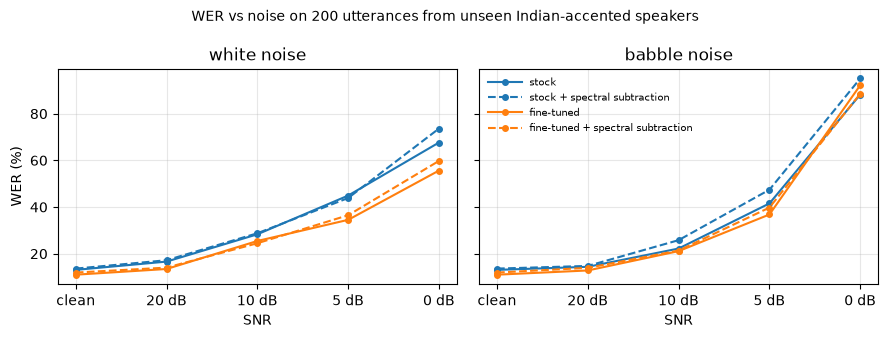


condition            stock     +SS   tuned     +SS
clean                13.1%   13.6%   11.0%   11.9%
white 20 dB          16.6%   17.2%   13.4%   14.0%
white 10 dB          28.3%   28.8%   25.4%   24.5%
white 5 dB           44.9%   43.9%   34.5%   36.5%
white 0 dB           67.7%   73.6%   55.6%   59.8%
babble 20 dB         14.4%   14.8%   12.8%   13.9%
babble 10 dB         22.2%   25.8%   21.1%   21.3%
babble 5 dB          41.5%   47.4%   36.8%   39.8%
babble 0 dB          88.2%   95.1%   92.2%   88.5%


In [30]:
import csv
import matplotlib.pyplot as plt

rows = list(csv.DictReader(open("eval/noise_study.csv", encoding="utf-8")))
snr = list(csv.DictReader(open("eval/noise_study_snr.csv", encoding="utf-8")))
print("signal-to-noise ratio before -> after spectral subtraction (dB):")
for r in snr:
    print(f"  {r['noise']:6} {r['snr_in']:>3} dB -> {float(r['snr_denoised']):5.1f} dB "
          f"({float(r['snr_denoised']) - float(r['snr_noisy']):+.1f})")

def wer(model, noise, s, d):
    for r in rows:
        if r["model"] == model and r["noise"] == noise and r["snr_db"] == s and r["denoise"] == str(d):
            return 100 * float(r["wer"])
    return float("nan")

levels = ["20", "10", "5", "0"]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), sharey=True)
styles = {("base.en", 0): ("tab:blue", "-", "stock"),
          ("base.en", 1): ("tab:blue", "--", "stock + spectral subtraction"),
          ("whisper-base-en-svarah", 0): ("tab:orange", "-", "fine-tuned"),
          ("whisper-base-en-svarah", 1): ("tab:orange", "--", "fine-tuned + spectral subtraction")}
for ax, noise in zip(axes, ["white", "babble"]):
    for (model, d), (c, ls, label) in styles.items():
        xs = ["clean"] + [f"{l} dB" for l in levels]
        ys = [wer(model, "clean", "", d)] + [wer(model, noise, l, d) for l in levels]
        ax.plot(xs, ys, ls, color=c, marker="o", ms=4, label=label)
    ax.set_title(f"{noise} noise"); ax.set_xlabel("SNR")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("WER (%)")
axes[1].legend(fontsize=7, frameon=False, handlelength=3.5)   # long enough to show dashes
fig.suptitle("WER vs noise on 200 utterances from unseen Indian-accented speakers", fontsize=10)
plt.tight_layout(); plt.show()

print(f"\n{'condition':<18}{'stock':>8}{'+SS':>8}{'tuned':>8}{'+SS':>8}")
for noise in ["clean", "white", "babble"]:
    for l in ([""] if noise == "clean" else levels):
        cells = [wer(m, noise, l, d) for m in ("base.en", "whisper-base-en-svarah") for d in (0, 1)]
        print(f"{noise + (' ' + l + ' dB' if l else ''):<18}" + "".join(f"{c:7.1f}%" for c in cells))

## 14B.9 · Questions: pitch versus word order, and ISL word order

**Can intonation tell a question from a statement?** `src/prosody.py` measures the final
pitch movement — median F0 of the last 300 ms of voiced speech against the rest, in semitones
(so low and high voices compare fairly) — with the same autocorrelation tracker. On Svarah's
387 spoken questions and 387 statements (`tools/question_study.py`, threshold chosen on train
speakers only, results on unseen speakers):

In [31]:
import json, csv
from src import matcher, isl_order

q = json.load(open("eval/question_threshold.json"))
print(f"median final pitch movement: yes/no {q['median_rise_st']['yesno']:+.1f} st | "
      f"wh {q['median_rise_st']['wh']:+.1f} st | statements {q['median_rise_st']['statement']:+.1f} st")
h = q["heldout_dev_test"]
print(f"pitch alone (threshold {q['threshold_st']:+.2f} st, unseen speakers): balanced accuracy "
      f"{h['balanced_acc']*100:.1f}% (yes/no recall {h['yesno_recall']*100:.0f}%, "
      f"statements kept {h['statement_specificity']*100:.0f}%)")

rows = [r for r in csv.DictReader(open("eval/question_study.csv", encoding="utf-8")) if r["split"] != "train"]
def detected(t):
    return isl_order.detect_question(t, matcher.match(t, use_drive=False)["plan"])["type"] is not None
qs = [r for r in rows if r["kind"] != "statement"]; st = [r for r in rows if r["kind"] == "statement"]
for label, strip in [('word order + "?"', False), ('word order, "?" removed', True)]:
    f = lambda r: detected(r["text"].rstrip("?. ") if strip else r["text"])
    print(f"app detector, {label:24}: questions {sum(map(f, qs))}/{len(qs)}, "
          f"statements wrongly flagged {sum(map(f, st))}/{len(st)}")

median final pitch movement: yes/no -0.3 st | wh -2.6 st | statements -2.2 st
pitch alone (threshold -0.50 st, unseen speakers): balanced accuracy 66.5% (yes/no recall 45%, statements kept 88%)
app detector, word order + "?"        : questions 79/85, statements wrongly flagged 1/70
app detector, word order, "?" removed : questions 61/85, statements wrongly flagged 1/70


**Finding 9 — in read Indian English, yes/no questions do not rise; they fall less.** Median
final movement is about −0.3 semitones for yes/no questions against about −2.2 for statements
and −2.6 for wh-questions. Pitch alone separates them only modestly (≈ 66 % balanced accuracy),
and adding it to word-order cues mainly added false alarms on the training speakers. So the app
decides with word order (question word first, verb first, or "?") and **reports** the pitch
movement as evidence rather than letting it decide.

**ISL word order** (`src/isl_order.py`) then applies three low-risk rules inside each
sentence: time expressions first, negation last, a sentence-initial question word last
(only when it really asks — "Where **is** …?", not "When I was young …"). Full
verb-final order is not attempted: without reliable verb/object detection a wrong reorder is
worse than English order. A yes/no question is marked in ISL by raised eyebrows — a facial
marker isolated dictionary clips cannot show — so the UI states it instead.

In [32]:
from src import matcher, isl_order
for t in ["Where is the hospital?", "I go to school tomorrow.", "I never eat rice.",
          "Can you help me", "I am 25 years old. Meet me at 7:30."]:
    m = matcher.match(t, use_drive=False)
    order, rules = isl_order.reorder(m["plan"])
    qd = isl_order.detect_question(t, m["plan"])
    print(f"{t:38} -> {isl_order.gloss(m['plan'], order):34} {('[' + qd['type'] + '-question]') if qd['type'] else ''}")
    if rules:
        print(f"{'':41}{'; '.join(rules)}")

Where is the hospital?                 -> HOSPITAL WHERE                     [wh-question]
                                         question word last: where
I go to school tomorrow.               -> TOMORROW GO SCHOOL                 
                                         time first: tomorrow
I never eat rice.                      -> EAT RICE NEVER                     
                                         negation last: never
Can you help me                        -> CAN YOU HELP                       [yesno-question]
I am 25 years old. Meet me at 7:30.    -> TWENTY FIVE OLD MEET SEVEN THIRTY  


**Numbers** are signed as they are read: *25* → TWENTY FIVE, *2026* → TWO THOUSAND TWENTY
SIX, *7:30* → SEVEN THIRTY. The dictionary has no sign for forty, eighty or ninety, so a
number needing one is signed digit by digit (*45* → FOUR FIVE), which ISL signers also do.

## 14B.10 · Fixes and findings from live testing

The last round of changes came from using the app with real speech, which exposed problems
that the automated tests had not.

**Fingerspelling was unreadably fast — a timestamp bug.** Every alphabet clip held 45 frames
(1.5 s of signing) but was stamped as lasting 0.03 s, so the browser flashed each letter past.
The cause was the letter-cutting tool letting the encoder assign timestamps (`pts=None`); the
26 clips were re-timed to 30 fps and the tool fixed. Fingerspelling now defaults to 1.5× speed
(about one second per letter), adjustable in the page. The browser had also cached the broken
clips, so the server now sends `Cache-Control: no-cache` for clips (an unchanged file costs
only a 304 reply).

**Words are never silently dropped.** The default became: sign on this laptop → else fetch it
from Google Drive → else fingerspell it. "How about you, my boy?" plays
H-O-W A-B-O-U-T YOU MY BOY — *how* and *about* exist nowhere on the 15,462-file Drive except as
long explanation videos. Substituting a more general sign (*puppy* → dog) and ISL reordering
stay available as switches but are off by default, because both change what the listener
said.

**Very short phrases defeat every model.** A recorded "cricket match" (2.9 s) came out as
"Trickier to match" (fine-tuned), "To the cat match" (stock) and "Couldn't get the match"
(the 3× larger `small.en`). With no surrounding words the decoder has no context; in a full
sentence ("I play cricket and hockey") the word was recognised. The page now has a
**correction box**: if a word is misheard, the user types the right sentence and signs it with
the identical pipeline — logged as "typed", so it never counts as an ASR result.

In [33]:
import json
r = json.load(open("eval/asr_two_model_selection.json"))
w = r["wer"]
print(f"two-model selection on {r['utterances']} test utterances ({r['speakers']} unseen speakers):")
print(f"  fine-tuned alone              {w['fine_tuned_alone']*100:.2f}%")
print(f"  stock alone                   {w['stock_alone']*100:.2f}%")
print(f"  keep the more confident one   {w['pick_confident_margin_0.0']*100:.2f}%  "
      f"(stock chosen {r['stock_chosen']['margin_0.0']} times)")
print("decision:", r["decision"])

two-model selection on 620 test utterances (16 unseen speakers):
  fine-tuned alone              11.30%
  stock alone                   13.11%
  keep the more confident one   11.25%  (stock chosen 46 times)
decision: not adopted: at best 0.05 points better for twice the GPU time


**Finding 12 — combining two models did not help.** Running stock and fine-tuned Whisper and
keeping the transcript with the higher confidence (average log-probability) gave 11.25 % WER
against 11.30 % for the fine-tuned model alone, at twice the GPU time, so it was not adopted.
The fine-tuned model is wrong on some words the stock model gets right (*chicken* for
*cricket*), but per-utterance confidence does not identify those cases reliably.

## 14B.11 · Latency

Measured on one laptop (RTX 4050, 6 GB); the same sentence (`eval/sample.wav`, 4.4 s).

| Configuration | ASR time per sentence |
|---|---|
| CPU int8, on battery | ~3,100 ms |
| CPU int8, plugged in | ~1,600 ms |
| **GPU fp16 (current)** | **~150–250 ms** |

`src/asr.py` uses the GPU when one is present and falls back to CPU otherwise, so the same code
runs on a teammate's laptop without an NVIDIA card. Matching remains ~0–1 ms against a
3,855-phrase dictionary — Finding 1 (latency is entirely ASR-bound) still holds at 600× the
vocabulary.

## Phase 1 findings

**Finding 4 — fine-tuning helps the hardest accents most.** Test WER fell from ~13.2 % to 11.3 % (13.12 → 11.30 and 13.32 → 11.27 in two runs; the ±0.2 spread comes from Whisper's random temperature fallback, which the app also uses)
on speakers never seen in training; 14 of 16 improved, and the largest gains were on the
speakers the stock model handled worst.

**Finding 5 — for single words, embedding similarity is not meaning.** See 14B.4. The safe
alternative was a reviewed lexical resource, and the review caught real errors.

**Finding 10 — spectral subtraction raises SNR but does not help Whisper.** It improves SNR
by +3.7 to +7 dB on white noise but only +0.4 to +1 dB on babble (it assumes the noise
spectrum is steady — true of a fan, false of people talking). Yet WER got slightly *worse* in 15
of 18 noisy/clean conditions (e.g. fine-tuned, clean 11.0 % → 11.9 %; white 5 dB 34.5 % →
36.5 %). Whisper was trained on noisy audio and copes with noise better than with the "musical
noise" artefacts subtraction leaves behind — a known result for neural ASR. The switch
therefore stays off by default; the classic method is kept as a measured, explained baseline.

**Finding 11 — fine-tuning on accented speech also made Whisper more robust to noise.** The
fine-tuned model beats stock Whisper at every white-noise level (5 dB: 44.9 % → 34.5 %; 0 dB:
67.7 % → 55.6 %) and on babble down to 5 dB, though it never saw added noise in training.
At 0 dB babble both models fail (~90 % WER).

**Finding 8 — an octave error caught by testing, not by eye.** The first pitch tracker read a
330 Hz voice as 82.5 Hz. Autocorrelation peaks at every multiple of the period; choosing the
shortest strong peak fixed it (all synthetic test voices within ~1 Hz, white noise rejected).

**Finding 6 — counting ISL-omitted words as failures understated coverage.** On the held-out
set, ~12 points of the gap between "all words" and "ISL-signed" coverage are words ISL does
not sign at all.

**Finding 7 — a data-split mistake that would have inflated the headline.** Svarah's file
names look like speaker ids but are not. The first split put the same voices in train and test;
it was caught by counting distinct ids (≈2,900 vs 117 speakers) before training.

**Update to Finding 3.** On the second development laptop the browser's 16 kHz WAV path ran
in every recorded session, so the earlier all-fallback runs were specific to that machine. The
reason for any future fallback is now written to the results log
(`encode_error=` in the note column) instead of being silent.

---
# § 15 · Limitations — what this system genuinely cannot do

Stated plainly, and volunteered rather than extracted.

| # | Limitation | Why |
|---|---|---|
| 1 | **It is not translation** | Lexical retrieval into a dictionary of isolated signs (6 entries in Phase 0, ~3,850 in Phase 1) |
| 2 | **Word order is English** | ISL has its own grammar; clip order follows the English sentence |
| 3 | **No non-manual markers** | Facial expression, head tilt and mouthing carry grammar in ISL; isolated dictionary clips cannot express sentence-level non-manuals |
| 4 | **No co-articulation** | Real signing blends one sign into the next; hard cuts do not |
| 5 | **Unknown words are dropped** | Reported honestly via coverage rather than hidden |
| 6 | **Fingerspelling is a fallback** | Deaf signers do not fingerspell everything |
| 7 | **No Deaf-user evaluation** | We measured coverage and latency, **not comprehensibility** |
| 8 | **Whisper is a component, not a contribution** | The contribution is the retrieval pipeline and its honest evaluation |
| 9 | **Word-sense ambiguity** | One English word can need different signs (*train* the vehicle vs *train* a person). Ambiguous inflections are left unmapped rather than guessed (§ 14B.4) |
| 10 | **Synonyms reviewed for English, not by a signer** | `data/synonyms.csv` approvals check English meaning; whether the synonym's sign is acceptable ISL needs a Deaf reviewer |
| 11 | **Long "(Explanation)" videos unused** | The sign sits inside continuous signing; `data/trims.csv` waits for someone who knows ISL to mark it (e.g. *how*) |
| 12 | **ASR accuracy measured on Svarah and synthetic speech** | Real-voice scoring is built in (§ 13) but needs more speakers than the two developers |

## What broke first when we scaled from 6 words to ~3,850? (Phase 0 prediction, checked in Phase 1)

**Exact matching.** Coverage would rise, but precision of *meaning* would fall — ISLRTC itself
notes synonyms, homonyms and context-specific signs, so one English word can map to several ISL
signs and exact matching has no way to choose the right one.

That is precisely why Phase 1 moves to sentence embeddings [9] and phrase-level corpora [2].
Notably, **retrieval speed is not the bottleneck** — Finding 1 already showed matching is free.

*Phase 1 check:* the prediction held. Speed stayed at ~0–1 ms; the hard problems were meaning
(14B.4) and which inflections are safe to map. Sentence embeddings turned out to be unsafe at
the single-word level, so Phase 1 used a reviewed lexical resource instead.

---
# § 16 · Pending work

| Phase | Work | Status |
|---|---|---|
| **1** | Scale the vocabulary; GPU ASR; fine-tune Whisper on Indian English; synonyms with a reject option | **Done** — § 14B. Embeddings tried and rejected for single words (14B.4) |
| **2** | ISL word order (e.g. question words last, verb last); ISLTranslate [2] for phrase-level retrieval | Next — English word order is now the largest linguistic gap |
| **3** | Voice activity detection (Silero) for continuous input | Remove push-to-talk |
| **4** | Evaluation **with Deaf signers**; review of synonyms and explanation-video trims by ISL users; smoother clip transitions | Measure comprehensibility, not just coverage |

## The honest caveat about similarity thresholds

A cosine similarity score says **nothing** about linguistic correctness. It measures distance in an
embedding space trained on **English text** — it is a proxy for the similarity of the English, not
evidence that the retrieved ISL video is correct.

So thresholds must be calibrated against **manually reviewed** examples, and Phase 1 must keep a
reject option: showing nothing is better than confidently showing the wrong sign.

## Interim conclusion

**Phase 0 (Review 1):** a complete speech→ISL retrieval pipeline ran end to end on a laptop CPU
at roughly **1.3 s** median latency, covering **57%** of the demo sentence with a six-entry
vocabulary, using real ISL video recorded by Deaf signers.

**Phase 1:** the same architecture, unchanged in shape, now retrieves from **~4,000** local
dictionary phrases plus **~2,700** fetched from Google Drive on demand (anything else is
fingerspelled), recognises speech in **~0.2 s** on a laptop GPU with a Whisper model fine-tuned on
Indian-accented English (**~13.2 % → 11.3 % WER** on unseen speakers, two runs), and signs about
**two-thirds of the words ISL would sign** in held-out everyday sentences — reporting the rest
honestly as omitted, spelled or uncovered.

The Phase 0 vocabulary was small by design. The architecture — recognise, normalise, retrieve, fall back,
and **count what was missed** — is what the project set out to demonstrate, and it is vocabulary-agnostic.

---
# § 17 · References (IEEE format)

Numbered by order of first citation. Every entry was checked against the publisher's page.

[1] A. Radford, J. W. Kim, T. Xu, G. Brockman, C. McLeavey, and I. Sutskever, "Robust speech
recognition via large-scale weak supervision," in *Proc. 40th Int. Conf. Machine Learning
(ICML)*, PMLR vol. 202, 2023, pp. 28492–28518.
https://proceedings.mlr.press/v202/radford23a.html

[2] A. Joshi, S. Agrawal, and A. Modi, "ISLTranslate: Dataset for translating Indian Sign
Language," in *Findings of the Association for Computational Linguistics: ACL 2023*, Toronto,
Canada, 2023. https://aclanthology.org/2023.findings-acl.665/

[3] A. Joshi et al., "iSign: A benchmark for Indian Sign Language processing," in *Findings of the
Association for Computational Linguistics: ACL 2024*, 2024, pp. 10827–10844.
https://aclanthology.org/2024.findings-acl.643/

[4] A. Sridhar, R. G. Ganesan, P. Kumar, and M. Khapra, "INCLUDE: A large scale dataset for Indian
Sign Language recognition," in *Proc. 28th ACM Int. Conf. Multimedia*, 2020, pp. 1366–1375.

[5] N. C. Camgöz, S. Hadfield, O. Koller, H. Ney, and R. Bowden, "Neural sign language
translation," in *Proc. IEEE/CVF Conf. Computer Vision and Pattern Recognition (CVPR)*, 2018,
pp. 7784–7793.
https://openaccess.thecvf.com/content_cvpr_2018/html/Camgoz_Neural_Sign_Language_CVPR_2018_paper.html

[6] N. C. Camgöz, O. Koller, S. Hadfield, and R. Bowden, "Sign language transformers: Joint
end-to-end sign language recognition and translation," in *Proc. IEEE/CVF Conf. Computer Vision
and Pattern Recognition (CVPR)*, 2020, pp. 10023–10033.

[7] B. Saunders, N. C. Camgöz, and R. Bowden, "Progressive transformers for end-to-end sign
language production," in *Proc. European Conf. Computer Vision (ECCV)*, 2020, pp. 687–705.
https://link.springer.com/chapter/10.1007/978-3-030-58621-8_40

[8] P. Kapoor, R. Mukhopadhyay, S. B. Hegde, V. Namboodiri, and C. V. Jawahar, "Towards automatic
speech to sign language generation," in *Proc. Interspeech 2021*, 2021.
https://www.isca-archive.org/interspeech_2021/kapoor21_interspeech.html

[9] N. Reimers and I. Gurevych, "Sentence-BERT: Sentence embeddings using Siamese BERT-networks,"
in *Proc. 2019 Conf. Empirical Methods in Natural Language Processing (EMNLP-IJCNLP)*, Hong Kong,
2019, pp. 3982–3992. https://aclanthology.org/D19-1410/

[10] L. C. Quandt, A. Willis, M. Schwenk, K. Weeks, and R. Ferster, "Attitudes toward signing
avatars vary depending on hearing status, age of signed language acquisition, and avatar type,"
*Frontiers in Psychology*, vol. 13, art. 730917, 2022.
https://www.frontiersin.org/journals/psychology/articles/10.3389/fpsyg.2022.730917/full

[12] T. Javed, S. Joshi, V. Nagarajan, S. Sundaresan, J. Nawale, A. Raman, K. Bhogale, P. Kumar,
and M. M. Khapra, "Svarah: Evaluating English ASR systems on Indian accents," in *Proc.
Interspeech 2023*, 2023. https://arxiv.org/abs/2305.15760

[13] G. A. Miller, "WordNet: A lexical database for English," *Communications of the ACM*,
vol. 38, no. 11, pp. 39–41, 1995.

*[12]–[13] were added in Phase 1.*

**Additional source consulted**

[11] M. Kipp, A. Heloir, and Q. Nguyen, "Assessing the deaf user perspective on sign language
avatars," in *Proc. 13th Int. ACM SIGACCESS Conf. Computers and Accessibility (ASSETS)*, 2011.
https://dl.acm.org/doi/10.1145/2049536.2049557

**Data sources**

- ISLRTC Indian Sign Language Dictionary — https://islrtc.nic.in/isl-dictionary/
- Government of India Open Data, ISL Dictionary — https://data.gov.in/catalog/indian-sign-language-dictionary
- ISL alphabet clips, FDMSE / RKMVERI Coimbatore — https://indiansignlanguage.org/category/alphabets/
- ISL Dictionary videos (Google Drive mirror used in Phase 1) — https://drive.google.com/drive/folders/1U-Pr4r1-cupgNOOq9NH_uTsQnPSVEKco
- Svarah (AI4Bharat, CC BY 4.0) — https://huggingface.co/datasets/ai4bharat/Svarah
- Word frequency list (google-10000-english) — https://github.com/first20hours/google-10000-english

---

*End of notebook.*